# NeqSim × Equinor TimeSeriesAnalysis
## From a large process model to an explainable dynamic digital twin

**An executable engineering mini-book · synthetic gas-processing facility · Python, Java and .NET**

[Open in Colab](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/advanced_analytics/neqsim_timeseriesanalysis_large_process.ipynb)

How can we use a thermodynamic simulator and industrial time-series models together to make better operating decisions? This notebook builds a six-train facility, checks its balances, learns dynamic responses, detects a compressor-efficiency change and evaluates constrained load allocation. It then assembles connected time-series models and screens a temperature-control loop.

The actual Equinor [TimeSeriesAnalysis](https://github.com/equinor/TimeSeriesAnalysis) .NET library is called through Python.NET. NeqSim is called through JPype. No commercial simulator, historian credentials or proprietary plant data are required.

### Reading route

1. **Reproducible setup:** load both runtimes and prove their origins.
2. **Steady-state facility:** six composable NeqSim trains, a common export header and balance audits.
3. **Steady analytics:** operating envelopes and constrained load allocation, with full-physics replay.
4. **Dynamic analytics:** physical thermal storage, system identification and chronological validation.
5. **Plant analytics:** connected models, compressor diagnostics and a PID screening example.
6. **Scale and handoff:** measured timing, validity limits, machine-readable outputs and exercises.

**Model boundary.** The steady process uses NeqSim equipment and SRK phase equilibrium. Dynamics use an explicitly defined lumped thermal balance and TimeSeriesAnalysis reduced models. These are real time-dependent calculations, but they do not resolve vessel phase inventories, pipeline waves, compressor surge or native NeqSim transient equipment. The distinction matters when choosing a model for an operating decision.

## 1. Reproducible setup

Run in a **fresh Linux x86-64 Colab runtime** with Python 3.12 and Java 17 or later. The first run downloads a pinned .NET SDK and compiles a pinned NeqSim master revision; allow several minutes and roughly 1 GB of free disk space. Subsequent calculations reuse the runtimes. Restart the notebook runtime before changing either Java or .NET assemblies.

The NeqSim revision below was master when this notebook was prepared. Pinning it makes the saved results reproducible. TimeSeriesAnalysis 1.4.38 is obtained from NuGet, including its declared dependencies. The older Python examples in its source repository do not all use the current signatures; the calls here have been executed against the pinned assembly.

An optional `NEQSIM_VALIDATED_RUNTIME` manifest supports an already compiled, audited local runtime. Its source revision and JAR hash must match. This is the route used for the saved execution; the fresh-Colab download/build route is provided but was not independently exercised in Google's hosted service.

In [1]:
import hashlib
import importlib.metadata as metadata
import json
import os
from pathlib import Path
import platform
import shutil
import subprocess
import sys
import tarfile
import time
import urllib.request
import zipfile

PYTHON_PACKAGES = {
    "numpy": "2.3.5",
    "pandas": "2.2.3",
    "scipy": "1.17.0",
    "matplotlib": "3.10.8",
    "JPype1": "1.7.1",
    "pythonnet": "3.1.0",
}
missing = []
for package, required_version in PYTHON_PACKAGES.items():
    try:
        present_version = metadata.version(package)
    except metadata.PackageNotFoundError:
        present_version = None
    if present_version != required_version:
        missing.append(f"{package}=={required_version}")
if missing:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)

NEQSIM_SOURCE_REF = "f3e588cec56fce818b723b3c0cb94c3619509d41"
TSA_VERSION = "1.4.38"
SDK_VERSION = "8.0.414"
SDK_SHA512 = (
    "bdf6b151f787ac57d393e625e8b8fc8e19ac75902e76227da736f20e042cf7ff9"
    "8bfd1a6669b77fdea7bfe678a0f23103e0cace1db83e9aee568ccd6f1b5b264"
)
work = Path("neqsim_tsa_runtime").resolve()
work.mkdir(exist_ok=True)
manifest_path = os.environ.get("NEQSIM_VALIDATED_RUNTIME")


def run_logged(command, cwd, filename, env=None):
    log = work / filename
    with log.open("w") as handle:
        result = subprocess.run(command, cwd=cwd, env=env, stdout=handle, stderr=handle)
    if result.returncode:
        raise RuntimeError(f"Command failed; inspect {log}\n{log.read_text()[-5000:]}")


if manifest_path:
    runtime = json.loads(Path(manifest_path).read_text())
    assert runtime["source_commit"] == NEQSIM_SOURCE_REF
    source_root = Path(runtime["source_root"])
    source_jar = Path(runtime["jar"])
    assert hashlib.sha256(source_jar.read_bytes()).hexdigest() == runtime["jar_sha256"]
    dotnet_root = Path(runtime["dotnet_root"])
    tsa_dir = Path(runtime["tsa_dir"])
    setup_route = "Audited prebuilt source and .NET runtime"
else:
    assert platform.system() == "Linux" and platform.machine() in ("x86_64", "AMD64")
    source_root = work / "neqsim-source"
    if not (source_root / ".git").exists():
        source_root.mkdir(exist_ok=True)
        run_logged(["git", "init"], source_root, "git-init.log")
        run_logged(
            ["git", "remote", "add", "origin", "https://github.com/equinor/neqsim.git"],
            source_root,
            "git-remote.log",
        )
        run_logged(
            ["git", "fetch", "--depth", "1", "origin", NEQSIM_SOURCE_REF],
            source_root,
            "git-fetch.log",
        )
        run_logged(["git", "checkout", "--detach", "FETCH_HEAD"], source_root, "git.log")
    resolved = subprocess.check_output(
        ["git", "rev-parse", "HEAD"], cwd=source_root, text=True
    ).strip()
    assert resolved == NEQSIM_SOURCE_REF
    if not shutil.which("javac"):
        run_logged(["apt-get", "update", "-qq"], work, "apt-update.log")
        run_logged(
            ["apt-get", "install", "-y", "-qq", "openjdk-17-jdk-headless"],
            work,
            "jdk-install.log",
        )
    run_logged(
        [
            "bash",
            "mvnw",
            "-q",
            "-Dmaven.test.skip=true",
            "-Dspotless.skip=true",
            "compile",
            "dependency:copy-dependencies",
            "-DincludeScope=runtime",
        ],
        source_root,
        "neqsim-build.log",
    )
    source_jar = source_root / "target/neqsim-verified.jar"
    with zipfile.ZipFile(source_jar, "w", zipfile.ZIP_DEFLATED) as archive:
        for item in sorted((source_root / "target/classes").rglob("*")):
            if item.is_file():
                archive.write(item, item.relative_to(source_root / "target/classes"))
    dotnet_root = work / "dotnet"
    if not (dotnet_root / "dotnet").exists():
        sdk_archive = work / "dotnet-sdk.tar.gz"
        sdk_url = (
            f"https://builds.dotnet.microsoft.com/dotnet/Sdk/{SDK_VERSION}/"
            f"dotnet-sdk-{SDK_VERSION}-linux-x64.tar.gz"
        )
        urllib.request.urlretrieve(sdk_url, sdk_archive)
        assert hashlib.sha512(sdk_archive.read_bytes()).hexdigest() == SDK_SHA512
        with tarfile.open(sdk_archive) as archive:
            archive.extractall(dotnet_root, filter="data")
    bridge = work / "bridge"
    bridge.mkdir(exist_ok=True)
    project = bridge / "TsaBridge.csproj"
    project.write_text(
        '<Project Sdk="Microsoft.NET.Sdk"><PropertyGroup>'
        "<TargetFramework>net8.0</TargetFramework>"
        "<GenerateRuntimeConfigurationFiles>true</GenerateRuntimeConfigurationFiles>"
        "<CopyLocalLockFileAssemblies>true</CopyLocalLockFileAssemblies>"
        "</PropertyGroup><ItemGroup>"
        f'<PackageReference Include="TimeSeriesAnalysis" Version="{TSA_VERSION}" />'
        "</ItemGroup></Project>"
    )
    tsa_dir = work / "tsa"
    build_env = dict(os.environ, DOTNET_ROOT=str(dotnet_root), DOTNET_CLI_TELEMETRY_OPTOUT="1")
    run_logged(
        [
            str(dotnet_root / "dotnet"),
            "publish",
            str(project),
            "-c",
            "Release",
            "-o",
            str(tsa_dir),
            "-v",
            "quiet",
        ],
        work,
        "tsa-build.log",
        build_env,
    )
    setup_route = "Pinned source build and pinned NuGet restore"
print(setup_route)
print("NeqSim source:", NEQSIM_SOURCE_REF)
print("TimeSeriesAnalysis NuGet:", TSA_VERSION)

Audited prebuilt source and .NET runtime
NeqSim source: f3e588cec56fce818b723b3c0cb94c3619509d41
TimeSeriesAnalysis NuGet: 1.4.38


In [2]:
os.environ["DOTNET_ROOT"] = str(dotnet_root)
os.environ["NEQSIM_JVM_AUTOSTART"] = "0"
from pythonnet import load

load("coreclr", runtime_config=str(tsa_dir / "TsaBridge.runtimeconfig.json"))
sys.path.insert(0, str(tsa_dir))
import clr

tsa_assembly = clr.AddReference("TimeSeriesAnalysis")
from System import Array, Double
from System.Collections.Generic import List
from TimeSeriesAnalysis import TimeSeriesDataSet
from TimeSeriesAnalysis.Dynamic import (
    ISimulatableModel,
    PidModel,
    PidParameters,
    PlantSimulator,
    SignalType,
    UnitDataSet,
    UnitIdentifier,
    UnitModel,
    UnitParameters,
)

import jpype
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq, minimize
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_rows", None)

assert not jpype.isJVMStarted(), "Restart the runtime before reloading the source JAR."
jpype.addClassPath(str(source_jar))
for dependency in sorted((source_root / "target/dependency").glob("*.jar")):
    jpype.addClassPath(str(dependency))
jpype.startJVM("-Xmx3g", convertStrings=True)
jneqsim = jpype.JPackage("neqsim")
SystemSrkEos = jpype.JClass("neqsim.thermo.system.SystemSrkEos")
class_origin = str(SystemSrkEos.class_.getProtectionDomain().getCodeSource().getLocation())
assert source_jar.name in class_origin
# This source sentinel is absent from the released 3.20.0 Java bundle.
# It verifies the source runtime; this notebook does not use automatic recycle construction.
SourceSentinel = jpype.JClass("neqsim.process.processmodel.AutoRecycleBuilder")
sentinel_origin = str(SourceSentinel.class_.getProtectionDomain().getCodeSource().getLocation())
assert sentinel_origin == class_origin
assert Path(str(tsa_assembly.Location)).resolve() == (tsa_dir / "TimeSeriesAnalysis.dll").resolve()
assert str(tsa_assembly.GetName().Version).startswith(TSA_VERSION)
provenance = {
    "NeqSim source": NEQSIM_SOURCE_REF,
    "Source runtime assertion": "SRK and master-only sentinel loaded from source JAR",
    "JAR SHA-256": hashlib.sha256(source_jar.read_bytes()).hexdigest(),
    "TSA assembly": str(tsa_assembly.GetName().Version),
    "TSA DLL SHA-256": hashlib.sha256(
        (tsa_dir / "TimeSeriesAnalysis.dll").read_bytes()
    ).hexdigest(),
    "Python": platform.python_version(),
    "Java": str(jpype.JClass("java.lang.System").getProperty("java.version")),
    "setup": setup_route,
}
display(pd.Series(provenance, name="Executed runtime").to_frame())

plt.rcParams.update(
    {
        "figure.figsize": (11, 5),
        "figure.dpi": 120,
        "savefig.dpi": 150,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.alpha": 0.18,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
    }
)
COLORS = ["#007C91", "#EC6B35", "#4353A3", "#AB4680", "#679B32", "#8A663A"]
outdir = Path("neqsim_tsa_results")
outdir.mkdir(exist_ok=True)
figures = []
checks = []


def check(name, condition, detail):
    checks.append({"Check": name, "Passed": bool(condition), "Evidence": str(detail)})
    assert condition, f"{name}: {detail}"


def finish(fig, name):
    fig.tight_layout()
    fig.savefig(outdir / f"{name}.png", bbox_inches="tight")
    figures.append(name)
    plt.show()


def netarray(values):
    return Array[Double]([float(value) for value in values])


def unit_model(name, gains, bias=0.0, tau=0.0, reference=None):
    parameters = UnitParameters()
    parameters.LinearGains = netarray(gains)
    parameters.U0 = netarray(np.zeros(len(gains)) if reference is None else reference)
    parameters.Bias = float(bias)
    parameters.TimeConstant_s = float(tau)
    return UnitModel(parameters, name)


print("Both libraries loaded; runtime origins and assembly version verified.")

Both libraries loaded; runtime origins and assembly version verified.


,Executed runtime
NeqSim source,f3e588cec56fce818b723b3c0cb94c3619509d41
Source runtime assertion,SRK and master-only sentinel loaded from source JAR
JAR SHA-256,4f082a3337f9b29331e2062da96cd86c4151cb185dbdf6d4d883f07e48da460b
TSA assembly,1.4.38.0
TSA DLL SHA-256,4a1294abf307dbc617b1426c8f24e92166f18d4e6fceb9e90a07818db32d7624
Python,3.12.14
Java,17.0.20
setup,Audited prebuilt source and .NET runtime


## 2. The facility: six trains and one export header

Each train contains a feed, inlet separator, three compressors, three coolers and three knockout drums: **11 named NeqSim units per train**, plus the common mixer. The six `ProcessSystem` objects and header system are added to a `ProcessModel` and remain available for extension. Intermediate streams are held in a train dictionary.

Feed conditions are 30 bara and 45 °C. Compression proceeds to 65, 115 and 180 bara, with each cooler specified at 32 °C. The six nominal isentropic efficiencies differ. A synthetic off-design efficiency curve is used in the load-allocation and diagnostic experiments. Pressure losses, anti-surge recycle, driver losses and compressor maps are outside this example.

The fluid uses the SRK equation of state, classical mixing rule 2 and multiphase checking. Composition is on a molar basis. Water is a small illustrative component; this is not a qualified water-solubility or dehydration model. Liquid streams include every liquid phase from each separator.

In [3]:
composition = {
    "methane": 0.82,
    "ethane": 0.08,
    "propane": 0.045,
    "n-butane": 0.025,
    "n-pentane": 0.012,
    "n-hexane": 0.007,
    "CO2": 0.009,
    "water": 0.002,
}
check("Mole fractions sum to one", abs(sum(composition.values()) - 1) < 1e-12, composition)
TRAIN_NAMES = [f"Train {letter}" for letter in "ABCDEF"]
ETA_NOMINAL = np.array([0.78, 0.76, 0.75, 0.79, 0.73, 0.77])
DRIVER_MW = np.array([5.6, 5.8, 5.75, 5.7, 5.9, 5.7])


def build_train(name, rate=20.0, nominal_efficiency=0.76, suction_bara=30.0):
    fluid = SystemSrkEos(318.15, float(suction_bara))
    for component, mole_fraction in composition.items():
        fluid.addComponent(component, mole_fraction)
    fluid.setMixingRule(2)
    fluid.setMultiPhaseCheck(True)
    process = jneqsim.process.processmodel.ProcessSystem(name)
    feed = jneqsim.process.equipment.stream.Stream(f"{name}: feed", fluid)
    feed.setFlowRate(float(rate), "kg/sec")
    separator = jneqsim.process.equipment.separator.Separator(f"{name}: inlet KO", feed)
    process.add(feed)
    process.add(separator)
    current = separator.getGasOutStream()
    liquids = [separator.getLiquidOutStream()]
    compressors, coolers, stages = [], [], []
    efficiency = nominal_efficiency - 0.08 * ((rate - 20.0) / 20.0) ** 2
    for stage_number, pressure in enumerate([65.0, 115.0, 180.0], start=1):
        compressor = jneqsim.process.equipment.compressor.Compressor(
            f"{name}: compressor {stage_number}", current
        )
        compressor.setOutletPressure(pressure)
        compressor.setIsentropicEfficiency(float(efficiency))
        cooler = jneqsim.process.equipment.heatexchanger.Cooler(
            f"{name}: cooler {stage_number}", compressor.getOutletStream()
        )
        cooler.setOutTemperature(305.15)
        knockout = jneqsim.process.equipment.separator.Separator(
            f"{name}: KO {stage_number}", cooler.getOutletStream()
        )
        for equipment in [compressor, cooler, knockout]:
            process.add(equipment)
        compressors.append(compressor)
        coolers.append(cooler)
        stages.append((compressor, cooler, knockout))
        liquids.append(knockout.getLiquidOutStream())
        current = knockout.getGasOutStream()
    return {
        "name": name,
        "process": process,
        "feed": feed,
        "gas": current,
        "liquids": liquids,
        "compressors": compressors,
        "coolers": coolers,
        "stages": stages,
        "efficiency": efficiency,
    }


def enthalpy_kw(stream):
    return stream.getFluid().getEnthalpy("J/kg") * stream.getFlowRate("kg/sec") / 1000.0


def train_results(train):
    feed = train["feed"].getFlowRate("kg/sec")
    gas = train["gas"].getFlowRate("kg/sec")
    liquid = sum(stream.getFlowRate("kg/sec") for stream in train["liquids"])
    power = sum(item.getPower("kW") for item in train["compressors"])
    signed_heat = sum(item.getDuty("kW") for item in train["coolers"])
    outlet_h = enthalpy_kw(train["gas"]) + sum(enthalpy_kw(s) for s in train["liquids"])
    residual = enthalpy_kw(train["feed"]) + power + signed_heat - outlet_h
    return {
        "Train": train["name"],
        "Feed [kg/s]": feed,
        "Export [kg/s]": gas,
        "Liquids [kg/s]": liquid,
        "Power [MW]": power / 1000,
        "Cooling [MW]": -signed_heat / 1000,
        "Mass error [kg/s]": feed - gas - liquid,
        "Energy error [kW]": residual,
    }


t0 = time.perf_counter()
trains = [build_train(name, nominal_efficiency=eta) for name, eta in zip(TRAIN_NAMES, ETA_NOMINAL)]
facility = jneqsim.process.processmodel.ProcessModel()
for train in trains:
    facility.add(train["name"], train["process"])
    train["process"].run()
header_process = jneqsim.process.processmodel.ProcessSystem("Common export")
export_header = jneqsim.process.equipment.mixer.Mixer("Export header")
for train in trains:
    export_header.addStream(train["gas"])
header_process.add(export_header)
facility.add("Common export", header_process)
header_process.run()
facility_seconds = time.perf_counter() - t0
baseline = pd.DataFrame([train_results(train) for train in trains]).set_index("Train")
unit_count = sum(int(train["process"].getUnitOperations().size()) for train in trains) + 1
display(baseline.round(5))
print(f"Facility: {unit_count} NeqSim units, {baseline['Feed [kg/s]'].sum():.1f} kg/s feed")
print(f"Total compression: {baseline['Power [MW]'].sum():.3f} MW")
print(f"Initial construction and run: {facility_seconds:.2f} s on this runtime")

Facility: 67 NeqSim units, 120.0 kg/s feed
Total compression: 32.079 MW
Initial construction and run: 3.19 s on this runtime


,Feed [kg/s],Export [kg/s],Liquids [kg/s],Power [MW],Cooling [MW],Mass error [kg/s],Energy error [kW]
Train,,,,,,,
Train A,20.0,19.52694,0.47306,5.22879,9.37425,0.0,-0.0
Train B,20.0,19.52694,0.47306,5.36639,9.51185,0.0,-0.0
Train C,20.0,19.52694,0.47306,5.43794,9.58340,0.0,-0.0
Train D,20.0,19.52694,0.47306,5.16260,9.30806,0.0,-0.0
Train E,20.0,19.52694,0.47306,5.58692,9.73239,0.0,-0.0
Train F,20.0,19.52694,0.47306,5.29669,9.44216,0.0,-0.0


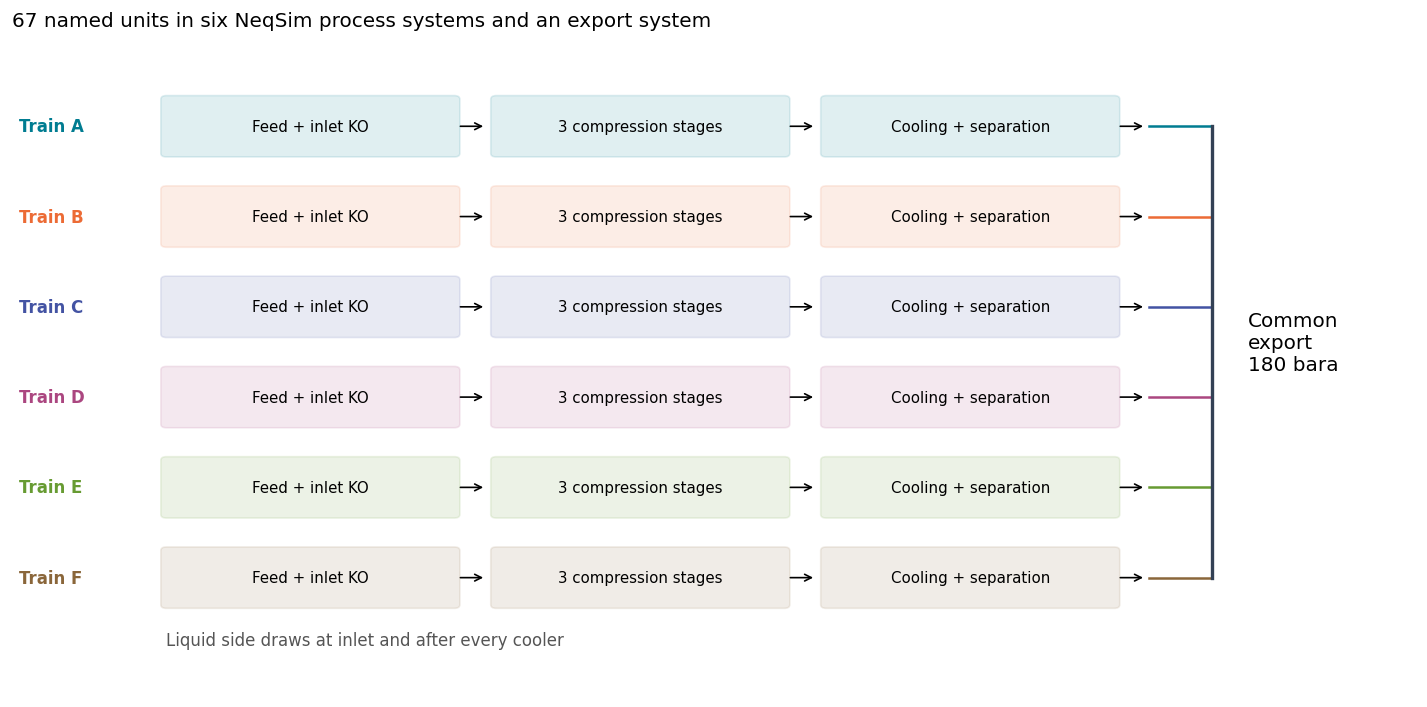

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.set(xlim=(0, 10), ylim=(-0.8, 6.5))
ax.axis("off")
labels = ["Feed + inlet KO", "3 compression stages", "Cooling + separation", "Export header"]
for train_index, name in enumerate(TRAIN_NAMES):
    y = 5.5 - train_index
    ax.text(0.05, y, name, va="center", weight="bold", color=COLORS[train_index])
    for x, label in zip([1.1, 3.45, 5.8], labels[:3]):
        box = FancyBboxPatch(
            (x, y - 0.3),
            2.05,
            0.6,
            boxstyle="round,pad=0.04",
            facecolor=COLORS[train_index],
            alpha=0.12,
            edgecolor=COLORS[train_index],
        )
        ax.add_patch(box)
        ax.text(x + 1.025, y, label, ha="center", va="center", fontsize=9)
        ax.annotate("", (x + 2.28, y), (x + 2.07, y), arrowprops={"arrowstyle": "->"})
    ax.plot([8.1, 8.55], [y, y], color=COLORS[train_index])
ax.plot([8.55, 8.55], [0.5, 5.5], color="#334155", lw=2)
ax.text(8.8, 3.1, "Common\nexport\n180 bara", va="center", fontsize=12)
ax.text(1.1, -0.25, "Liquid side draws at inlet and after every cooler", color="#555555")
ax.set_title(
    f"{unit_count} named units in six NeqSim process systems and an export system", loc="left"
)
finish(fig, "01_facility")

### Balance audit before analytics

For a steady open system, with heat into the fluid positive and compressor work positive:

$$\dot m_{in}-\sum_j\dot m_{out,j}=0$$
$$\dot H_{in}+\dot W+\dot Q-\sum_j\dot H_{out,j}=0$$

Mass flow is in kg/s; enthalpy rates, work and heat are in kW. Cooler duties from NeqSim are negative. The audit includes every liquid side draw. A component-molar balance provides a separate check against accidentally losing a light or heavy component.

,Check,Passed,Evidence
1,Train total mass balances,True,1.9617918400882672e-11
2,Train enthalpy balances,True,2.4556356947869062e-11
3,Component molar balances,True,9.948747990190384e-13
4,Header mass balance,True,-2.842170943040401e-14
5,Header energy balance,True,0.0
6,Physical power and cooling signs,True,All compressor powers and cooling requirements positive


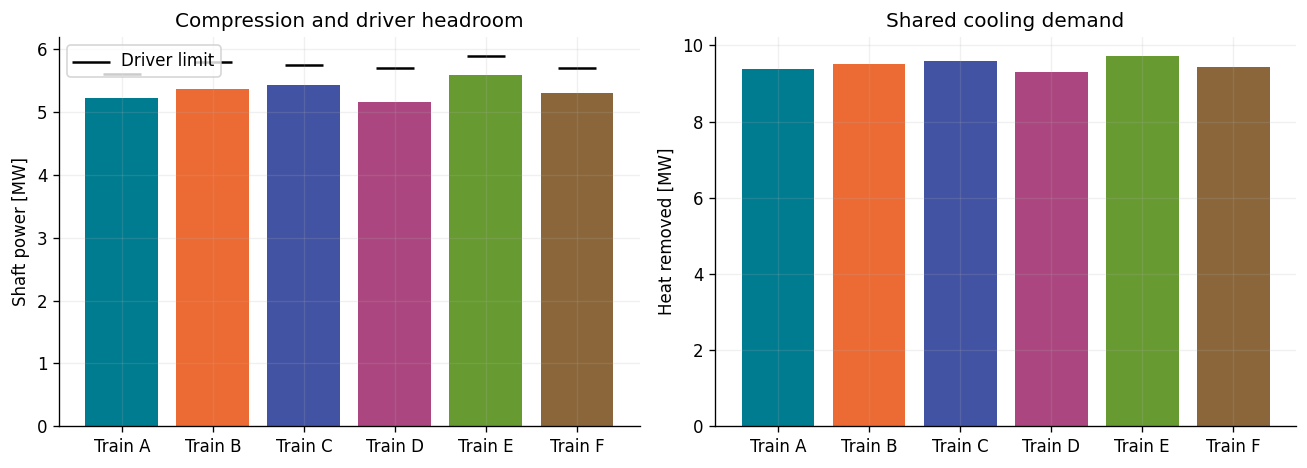

In [5]:
check(
    "Train total mass balances",
    baseline["Mass error [kg/s]"].abs().max() < 1e-7,
    baseline["Mass error [kg/s]"].abs().max(),
)
check(
    "Train enthalpy balances",
    baseline["Energy error [kW]"].abs().max() < 0.2,
    baseline["Energy error [kW]"].abs().max(),
)
component_errors = []
for train in trains:
    incoming = train["feed"].getFluid()
    products = [train["gas"], *train["liquids"]]
    for component in composition:
        feed_moles = incoming.getComponent(component).getNumberOfmoles()
        outlet_moles = sum(
            s.getFluid().getComponent(component).getNumberOfmoles() for s in products
        )
        component_errors.append(abs(feed_moles - outlet_moles) / max(abs(feed_moles), 1e-12))
check("Component molar balances", max(component_errors) < 1e-7, max(component_errors))
header_mass_error = (
    export_header.getOutletStream().getFlowRate("kg/sec") - baseline["Export [kg/s]"].sum()
)
header_energy_error = enthalpy_kw(export_header.getOutletStream()) - sum(
    enthalpy_kw(t["gas"]) for t in trains
)
check("Header mass balance", abs(header_mass_error) < 1e-7, header_mass_error)
check("Header energy balance", abs(header_energy_error) < 0.2, header_energy_error)
check(
    "Physical power and cooling signs",
    bool((baseline[["Power [MW]", "Cooling [MW]"]] > 0).all().all()),
    "All compressor powers and cooling requirements positive",
)
display(pd.DataFrame(checks).tail(6))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].bar(TRAIN_NAMES, baseline["Power [MW]"], color=COLORS)
axes[0].scatter(TRAIN_NAMES, DRIVER_MW, marker="_", s=500, color="black", label="Driver limit")
axes[0].set(ylabel="Shaft power [MW]", title="Compression and driver headroom")
axes[0].legend()
axes[1].bar(TRAIN_NAMES, baseline["Cooling [MW]"], color=COLORS)
axes[1].set(ylabel="Heat removed [MW]", title="Shared cooling demand")
finish(fig, "02_energy")

## 3. Steady-state analytics: allocate load with constraints

We sample each train at 13–27 kg/s using NeqSim, fit shape-preserving interpolation curves and minimize total shaft power at a fixed facility feed. Driver power, per-train flow bounds and a shared cooling limit are enforced. A 5 kW reserve below each driver rating accommodates interpolation error; the final NeqSim replay must stay below the actual ratings. The trained response curves are only valid inside this sampled range and at the stated pressure, composition and cooler temperature.

$$\min_{\dot m_1,\ldots,\dot m_6}\sum_i W_i(\dot m_i)$$
$$\sum_i\dot m_i=120\ \mathrm{kg/s},\quad W_i\leq W_{i,max},\quad\sum_i Q_i\leq Q_{max}$$

Here $W_i$ is shaft power in MW and $Q_i$ is the positive cooling requirement in MW. The optimization holds **feed** constant; it does not claim an export-gas optimum. After optimization, we rebuild the six full NeqSim trains at the candidate settings and check feasibility and balances again.

54 full train simulations in 7.50 s


Power [MW]        Cooling [MW]        
               min    max          min     max
Train                                         
Train A      3.442  7.149        6.137  12.745
Train B      3.534  7.339        6.228  12.936
Train C      3.581  7.438        6.276  13.035
Train D      3.398  7.057        6.092  12.653
Train E      3.681  7.645        6.375  13.241
Train F      3.487  7.243        6.182  12.839

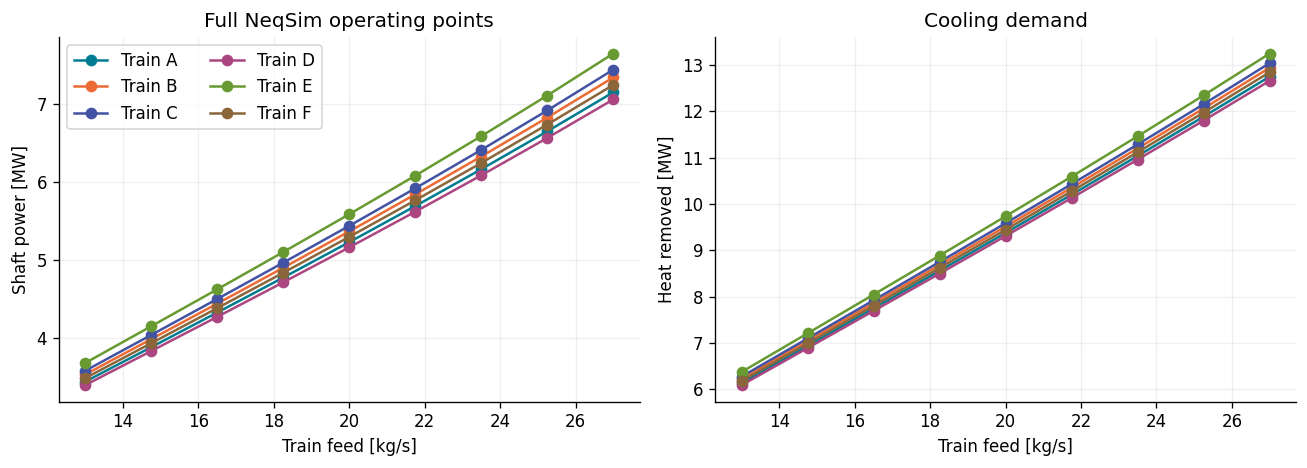

In [6]:
flow_grid = np.linspace(13, 27, 9)
scan_rows = []
scan_start = time.perf_counter()
for train_index, (name, efficiency) in enumerate(zip(TRAIN_NAMES, ETA_NOMINAL)):
    for flow in flow_grid:
        trial = build_train(name, float(flow), float(efficiency))
        trial["process"].run()
        result = train_results(trial)
        result["train_index"] = train_index
        scan_rows.append(result)
scan = pd.DataFrame(scan_rows)
scan_seconds = time.perf_counter() - scan_start
power_curves, cooling_curves = [], []
for train_index in range(6):
    subset = scan[scan.train_index == train_index]
    power_curves.append(
        PchipInterpolator(subset["Feed [kg/s]"], subset["Power [MW]"], extrapolate=False)
    )
    cooling_curves.append(
        PchipInterpolator(subset["Feed [kg/s]"], subset["Cooling [MW]"], extrapolate=False)
    )
check(
    "Scan balance closure",
    scan["Energy error [kW]"].abs().max() < 0.2,
    scan["Energy error [kW]"].abs().max(),
)
print(f"{len(scan)} full train simulations in {scan_seconds:.2f} s")
display(scan.groupby("Train")[["Power [MW]", "Cooling [MW]"]].agg(["min", "max"]).round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for index, name in enumerate(TRAIN_NAMES):
    subset = scan[scan.train_index == index]
    axes[0].plot(flow_grid, subset["Power [MW]"], "o-", color=COLORS[index], label=name)
    axes[1].plot(flow_grid, subset["Cooling [MW]"], "o-", color=COLORS[index], label=name)
axes[0].set(
    xlabel="Train feed [kg/s]", ylabel="Shaft power [MW]", title="Full NeqSim operating points"
)
axes[1].set(xlabel="Train feed [kg/s]", ylabel="Heat removed [MW]", title="Cooling demand")
axes[0].legend(ncol=2)
finish(fig, "03_operating_envelopes")

Synthetic-case shaft-power reduction at fixed feed: 0.051 MW
This is a local candidate under the assumed efficiency curves, not a proven global optimum.


,Base feed [kg/s],Candidate feed [kg/s],Replay power [MW],Driver margin [MW]
Train,,,,
Train A,20.0,21.390,5.595,0.005
Train B,20.0,20.529,5.509,0.291
Train C,20.0,19.278,5.242,0.508
Train D,20.0,22.039,5.695,0.005
Train E,20.0,15.272,4.292,1.608
Train F,20.0,21.492,5.695,0.005


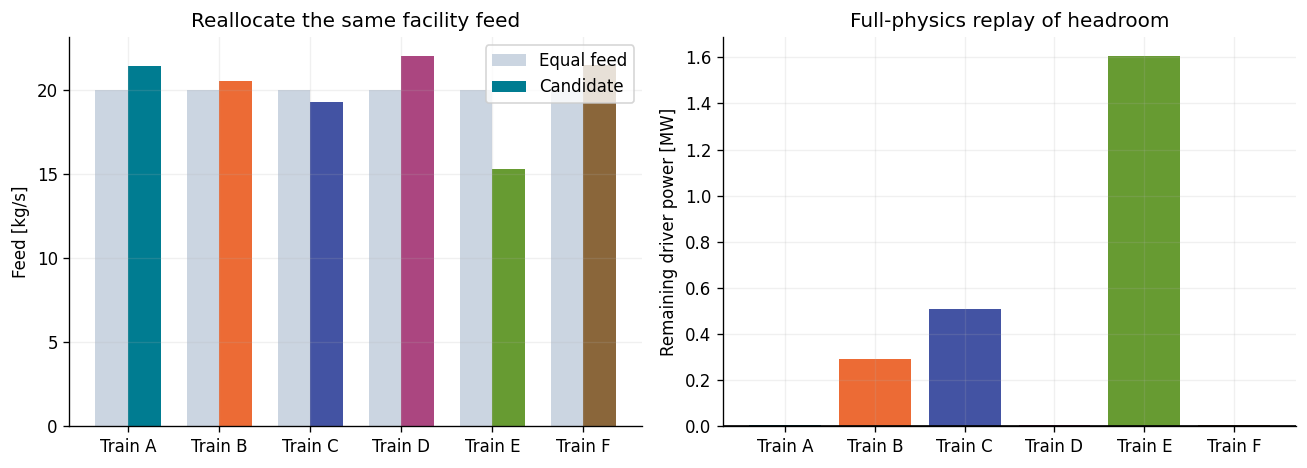

In [7]:
def response(curves, rates):
    return np.array([float(curve(rate)) for curve, rate in zip(curves, rates)])


cooling_limit = float(baseline["Cooling [MW]"].sum() * 1.02)
constraints = [
    {"type": "eq", "fun": lambda rates: rates.sum() - 120.0},
    {"type": "ineq", "fun": lambda rates: DRIVER_MW - 0.005 - response(power_curves, rates)},
    {"type": "ineq", "fun": lambda rates: cooling_limit - response(cooling_curves, rates).sum()},
]
opt = minimize(
    lambda rates: response(power_curves, rates).sum(),
    np.full(6, 20.0),
    method="SLSQP",
    bounds=[(13.0, 27.0)] * 6,
    constraints=constraints,
    options={"ftol": 1e-10, "maxiter": 150},
)
check("Load allocation solver", opt.success, opt.message)
replay_trains = [
    build_train(name, float(flow), float(efficiency))
    for name, flow, efficiency in zip(TRAIN_NAMES, opt.x, ETA_NOMINAL)
]
for train in replay_trains:
    train["process"].run()
replay = pd.DataFrame([train_results(train) for train in replay_trains]).set_index("Train")
check(
    "Replay fixed total feed",
    abs(replay["Feed [kg/s]"].sum() - 120) < 1e-6,
    replay["Feed [kg/s]"].sum(),
)
check(
    "Replay driver constraints",
    np.all(replay["Power [MW]"].values <= DRIVER_MW),
    float(np.max(replay["Power [MW]"].values - DRIVER_MW)),
)
check(
    "Replay cooling constraint",
    replay["Cooling [MW]"].sum() <= cooling_limit + 0.005,
    replay["Cooling [MW]"].sum(),
)
check(
    "Replay energy balances",
    replay["Energy error [kW]"].abs().max() < 0.2,
    replay["Energy error [kW]"].abs().max(),
)
interpolation_error = replay["Power [MW]"].values - response(power_curves, opt.x)
check(
    "Response curve accuracy at candidate",
    np.max(abs(interpolation_error)) < 0.005,
    np.max(abs(interpolation_error)),
)
saving_mw = baseline["Power [MW]"].sum() - replay["Power [MW]"].sum()
allocation = pd.DataFrame(
    {
        "Base feed [kg/s]": baseline["Feed [kg/s]"],
        "Candidate feed [kg/s]": opt.x,
        "Replay power [MW]": replay["Power [MW]"],
        "Driver margin [MW]": DRIVER_MW - replay["Power [MW]"],
    }
)
display(allocation.round(3))
print(f"Synthetic-case shaft-power reduction at fixed feed: {saving_mw:.3f} MW")
print(
    "This is a local candidate under the assumed efficiency curves, not a proven global optimum."
)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(6)
axes[0].bar(x - 0.18, np.full(6, 20), 0.36, label="Equal feed", color="#CBD5E1")
axes[0].bar(x + 0.18, opt.x, 0.36, label="Candidate", color=COLORS)
axes[0].set(
    xticks=x,
    xticklabels=TRAIN_NAMES,
    ylabel="Feed [kg/s]",
    title="Reallocate the same facility feed",
)
axes[0].legend()
axes[1].bar(TRAIN_NAMES, DRIVER_MW - replay["Power [MW]"], color=COLORS)
axes[1].axhline(0, color="black", lw=1)
axes[1].set(ylabel="Remaining driver power [MW]", title="Full-physics replay of headroom")
finish(fig, "04_load_allocation")

## 4. A physical dynamic experiment

A thermodynamic operating point does not contain a time constant. We add an explicit effective thermal capacitance for the first aftercooler of Train A. NeqSim supplies the inlet temperature, gas flow and heat capacity; the effective conductance is chosen so its steady outlet is 32 °C at an 18 °C cooling-water temperature.

$$C\frac{dT}{dt}=\dot m c_p(T_{in}-T)-UA(T-T_{cw})$$
$$T_{ss}=\frac{\dot m c_pT_{in}+UA T_{cw}}{\dot m c_p+UA},\qquad\tau=\frac{C}{\dot m c_p+UA}$$

$T$, $T_{in}$ and $T_{cw}$ are temperatures in °C, with differences in K. The effective capacitance $C$ is in kJ/K, $c_p$ in kJ/(kg K), $UA$ in kW/K and time $t$ in seconds. We set $C$ to give a nominal 45 s time constant. This is a stated synthetic equipment assumption, not a value inferred from NeqSim steady-state calculations.

The experiment varies inlet temperature and cooling-water temperature independently. Flow and heat capacity are fixed at the reference value. This lumped approximation is used to validate the integration and identification workflow; the phase-changing NeqSim cooler remains the steady reference, not the dynamic truth model. Real-data work needs independently excited inputs and a physically appropriate storage model.

The update below solves the linear energy equation exactly for each piecewise-constant input interval. That lets us check integrated energy storage independently of the TimeSeriesAnalysis discretization.

,Reference model
Hot inlet [°C],110.1383
Gas flow [kg/s],20.0000
NeqSim cp [kJ/(kg K)],2.5987
UA [kW/K],290.0799
Effective C [kJ/K],15392.4022
Physical tau [s],45.0000


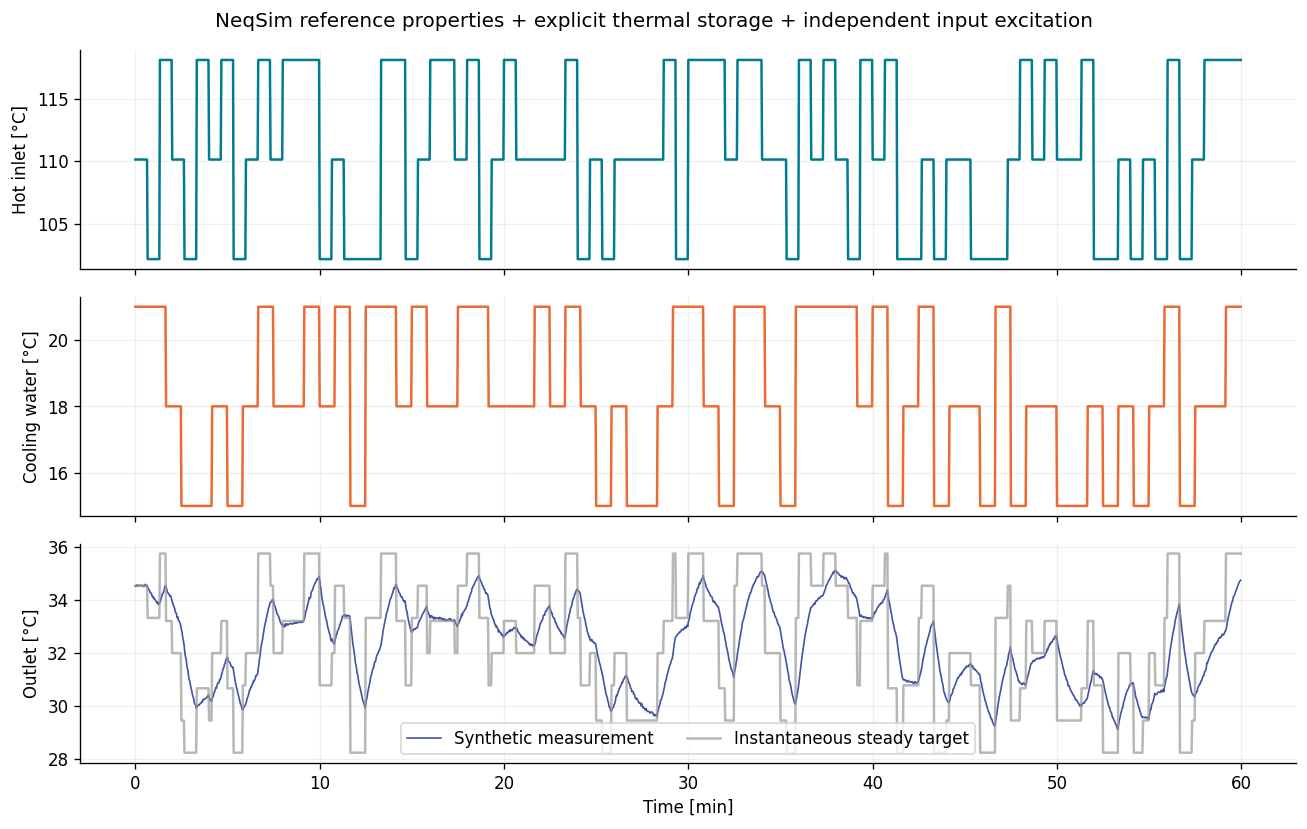

In [8]:
reference_hot_stream = trains[0]["compressors"][0].getOutletStream()
hot_temperature = reference_hot_stream.getTemperature("C")
gas_flow = reference_hot_stream.getFlowRate("kg/sec")
cp = reference_hot_stream.getFluid().getCp("kJ/kgK")
heat_capacity_rate = gas_flow * cp
coolant_reference = 18.0
outlet_reference = 32.0
conductance = (
    heat_capacity_rate
    * (hot_temperature - outlet_reference)
    / (outlet_reference - coolant_reference)
)
tau_true = 45.0
capacitance = tau_true * (heat_capacity_rate + conductance)
gains_true = np.array([heat_capacity_rate, conductance]) / (heat_capacity_rate + conductance)
dt = 2.0
sample_count = 1800
seconds = np.arange(sample_count) * dt
rng = np.random.default_rng(20260914)
inputs = np.column_stack(
    [
        hot_temperature + np.repeat(rng.choice([-8.0, 0.0, 8.0], 90), 20),
        coolant_reference + np.repeat(rng.choice([-3.0, 0.0, 3.0], 72), 25),
    ]
)
steady_temperature = inputs @ gains_true
temperature = np.empty(sample_count)
temperature[0] = steady_temperature[0]
decay = np.exp(-dt / tau_true)
energy_errors = []
for index in range(1, sample_count):
    target = steady_temperature[index]
    previous = temperature[index - 1]
    temperature[index] = target + (previous - target) * decay
    mean_temperature = target + (previous - target) * tau_true / dt * (1 - decay)
    net_heat = heat_capacity_rate * (inputs[index, 0] - mean_temperature)
    net_heat -= conductance * (mean_temperature - inputs[index, 1])
    stored_energy = capacitance * (temperature[index] - previous)
    energy_errors.append(stored_energy - dt * net_heat)
measurement = temperature + rng.normal(0, 0.025, sample_count)
check(
    "Integrated dynamic energy balance",
    max(abs(np.array(energy_errors))) < 1e-7,
    f"Maximum interval residual {max(abs(np.array(energy_errors))):.3g} kJ",
)
display(
    pd.Series(
        {
            "Hot inlet [°C]": hot_temperature,
            "Gas flow [kg/s]": gas_flow,
            "NeqSim cp [kJ/(kg K)]": cp,
            "UA [kW/K]": conductance,
            "Effective C [kJ/K]": capacitance,
            "Physical tau [s]": tau_true,
        }
    )
    .round(4)
    .to_frame("Reference model")
)
fig, axes = plt.subplots(3, 1, figsize=(11, 7), sharex=True)
axes[0].plot(seconds / 60, inputs[:, 0], color=COLORS[0])
axes[0].set(ylabel="Hot inlet [°C]")
axes[1].plot(seconds / 60, inputs[:, 1], color=COLORS[1])
axes[1].set(ylabel="Cooling water [°C]")
axes[2].plot(seconds / 60, measurement, color=COLORS[2], lw=1, label="Synthetic measurement")
axes[2].plot(
    seconds / 60,
    steady_temperature,
    color="#999999",
    alpha=0.7,
    label="Instantaneous steady target",
)
axes[2].set(xlabel="Time [min]", ylabel="Outlet [°C]")
axes[2].legend(ncol=2)
fig.suptitle(
    "NeqSim reference properties + explicit thermal storage + independent input excitation"
)
finish(fig, "05_dynamic_experiment")

### Historian quality and leakage rules

Preserve time order, units and quality flags. Do not bridge long gaps, treat frozen tags as measured dynamics, or randomly shuffle a dynamic experiment into training and test rows. Here we inject a short dropout and a frozen sensor period into a separate raw view, flag them, and show their positions. For fitting, a complete contiguous qualified interval is selected from the original synthetic experiment; the damaged copy is not silently interpolated into the training data.

Training uses the first 60% of the experiment, calibration the next 20%, and final testing the last 20%. Model coefficients are learned on training only. Calibration selects a residual threshold; test data assess its behavior. Final validation simulation is a continuous forward pass using inputs only. It never resets the model with future measured outputs.

,Flagged samples
missing,10
frozen,26


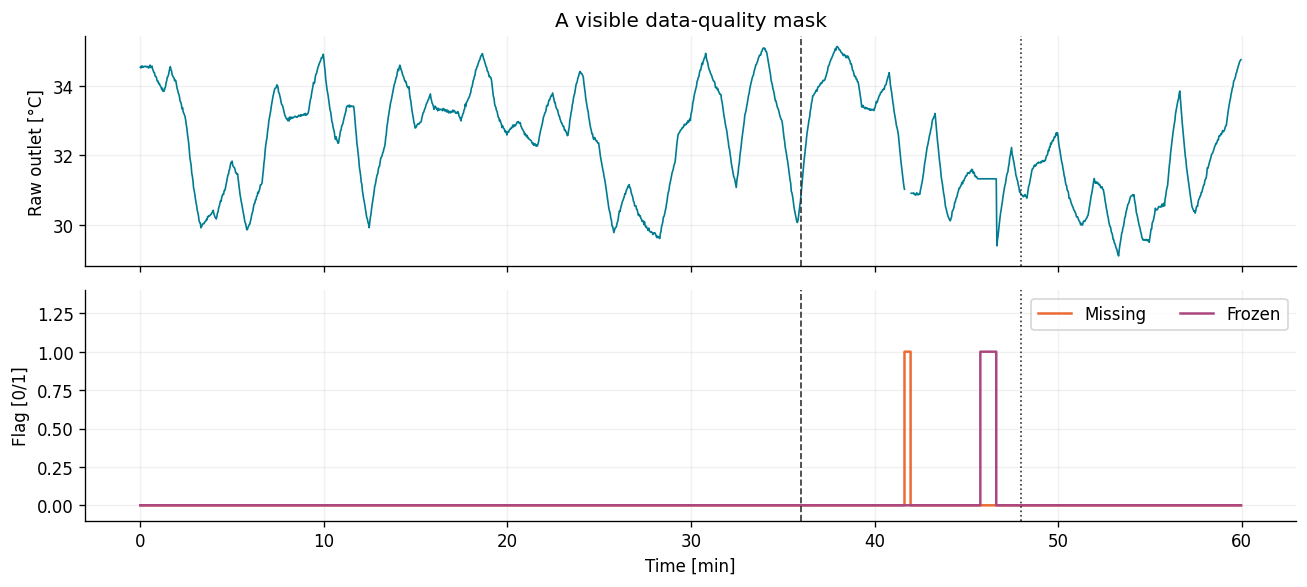

In [9]:
timestamps = pd.date_range("2026-01-01", periods=sample_count, freq="2s", tz="UTC")
historian = pd.DataFrame(
    {
        "hot_inlet_C": inputs[:, 0],
        "cooling_water_C": inputs[:, 1],
        "outlet_C": measurement,
    },
    index=timestamps,
)
raw_historian = historian.copy()
raw_historian.iloc[1250:1260, 2] = np.nan
raw_historian.iloc[1370:1400, 2] = raw_historian.iloc[1369, 2]
missing_flag = raw_historian.isna().any(axis=1)
frozen_flag = raw_historian.outlet_C.diff().abs().lt(1e-10).rolling(5).sum().ge(5)
quality = pd.DataFrame({"missing": missing_flag, "frozen": frozen_flag})
train_end, calibration_end = 1080, 1440
check(
    "Qualified contiguous training segment",
    not quality.iloc[:train_end].any().any(),
    f"Samples 0–{train_end - 1} have no injected quality failures",
)
display(quality.sum().rename("Flagged samples").to_frame())
fig, axes = plt.subplots(2, 1, figsize=(11, 5), sharex=True)
axes[0].plot(seconds / 60, raw_historian.outlet_C, color=COLORS[0], lw=1)
axes[0].set(ylabel="Raw outlet [°C]", title="A visible data-quality mask")
axes[1].step(seconds / 60, missing_flag.astype(int), label="Missing", color=COLORS[1])
axes[1].step(seconds / 60, frozen_flag.astype(int), label="Frozen", color=COLORS[3])
axes[1].set(xlabel="Time [min]", ylabel="Flag [0/1]", ylim=(-0.1, 1.4))
axes[1].legend(ncol=2)
for ax in axes:
    ax.axvline(seconds[train_end] / 60, color="#333333", ls="--", lw=1)
    ax.axvline(seconds[calibration_end] / 60, color="#333333", ls=":", lw=1)
finish(fig, "06_historian_quality")

## 5. Identify the dynamics with TimeSeriesAnalysis

The current API uses `UnitDataSet.SetU`, `CreateTimeStamps` and the static `UnitIdentifier.IdentifyLinear` method. Python.NET returns the model and updated `ref` dataset as a tuple. The fitted model is then simulated with `UnitModel.Iterate`.

We constrain this example to linear gains and disable transport-delay estimation because the known energy equation has no dead time. A measured plant may require a justified delay search, input nonlinearities or closed-loop identification. Residual performance alone is not evidence that all physical parameters are uniquely identifiable.

TimeSeriesAnalysis's first-order filter uses a backward-Euler coefficient, while the synthetic plant uses the exact exponential solution. Consequently, the fitted discrete-equivalent time constant differs slightly from the continuous 45 s value. We report both instead of treating that numerical difference as physical model error.

In [10]:
training = UnitDataSet("Aftercooler training")
training.SetU(netarray(inputs[:train_end, 0]), netarray(inputs[:train_end, 1]))
training.Y_meas = netarray(measurement[:train_end])
training.CreateTimeStamps(dt)
fit_start = time.perf_counter()
identified, fitted_data = UnitIdentifier.IdentifyLinear(training, None, False)
fit_seconds = time.perf_counter() - fit_start
fit_parameters = identified.GetModelParameters()
check(
    "TSA identification succeeded",
    fit_parameters.Fitting.WasAbleToIdentify,
    str(fit_parameters.Fitting.SolverID),
)
identified.WarmStart()
predicted = np.array([identified.Iterate(netarray(row), dt)[0] for row in inputs])
linear_design = np.column_stack([np.ones(train_end), inputs[:train_end]])
static_coefficients = np.linalg.lstsq(linear_design, measurement[:train_end], rcond=None)[0]
static_prediction = np.column_stack([np.ones(sample_count), inputs]) @ static_coefficients
tau_discrete_equivalent = dt / (np.exp(dt / tau_true) - 1)
fit_gains = np.array(list(fit_parameters.LinearGains))
parameter_table = pd.DataFrame(
    {
        "Physical model": [*gains_true, tau_true],
        "Expected discrete equivalent": [*gains_true, tau_discrete_equivalent],
        "Identified": [*fit_gains, fit_parameters.TimeConstant_s],
    },
    index=["Hot-inlet gain [K/K]", "Cooling-water gain [K/K]", "Time constant [s]"],
)
display(parameter_table.round(4))
warnings = [str(value) for value in fit_parameters.GetWarningList()]
print("Identification warnings:", warnings or "none")
print(f"Fit runtime: {fit_seconds:.3f} s; fitted time delay: {fit_parameters.TimeDelay_s:.1f} s")
check("Recovered process gains", np.max(abs(fit_gains - gains_true)) < 0.04, fit_gains)
check(
    "Recovered discrete time constant",
    abs(fit_parameters.TimeConstant_s - tau_discrete_equivalent) < 7,
    fit_parameters.TimeConstant_s,
)

Identification warnings: none
Fit runtime: 0.383 s; fitted time delay: 0.0 s


,Physical model,Expected discrete equivalent,Identified
Hot-inlet gain [K/K],0.1519,0.1519,0.1512
Cooling-water gain [K/K],0.8481,0.8481,0.8440
Time constant [s],45.0000,44.0074,43.6430


Calibration residual threshold: 0.060 K
Test threshold-exceedance fraction: 3.06%
The empirical calibration quantile does not guarantee the same exceedance rate on new data.


,TSA dynamic RMSE [K],Static regression RMSE [K]
Partition,,
Training,0.0254,1.0916
Calibration,0.0234,1.2560
Held-out test,0.0264,1.2811


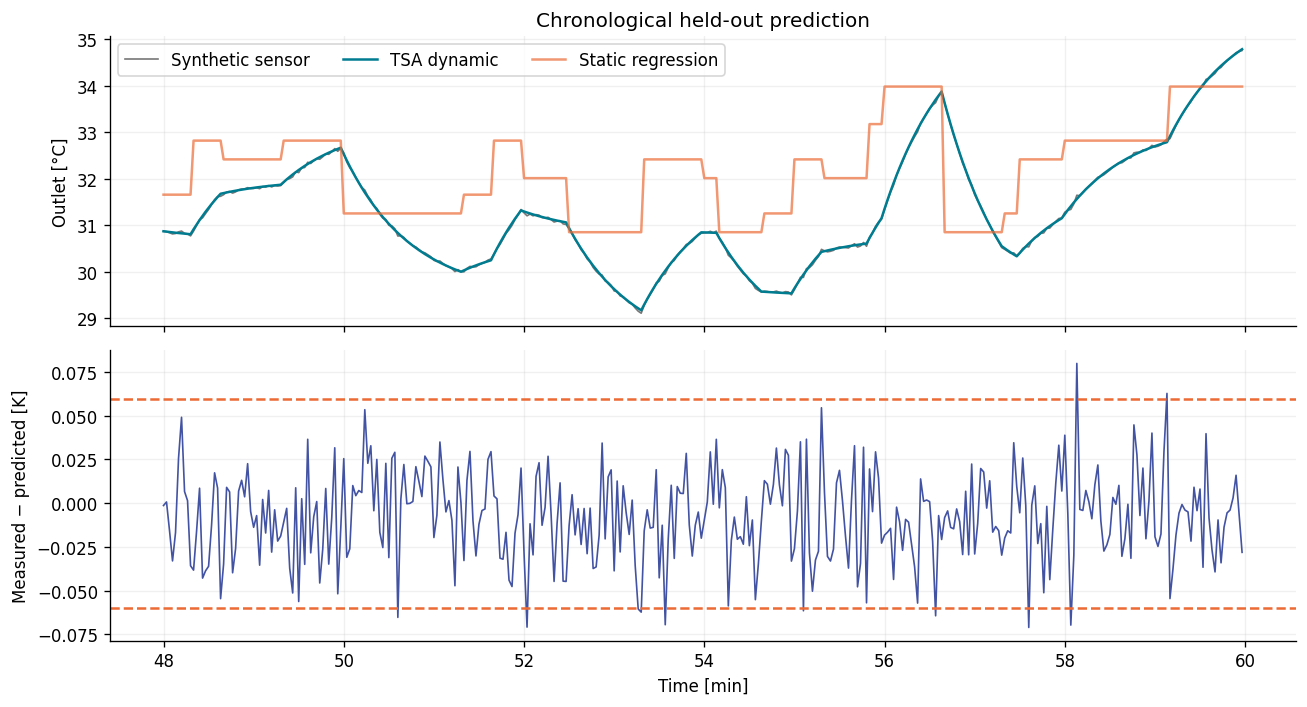

In [11]:
def rmse(observed, estimated):
    return float(np.sqrt(np.mean((np.asarray(observed) - np.asarray(estimated)) ** 2)))


partitions = {
    "Training": slice(100, train_end),
    "Calibration": slice(train_end, calibration_end),
    "Held-out test": slice(calibration_end, sample_count),
}
scores = pd.DataFrame(
    [
        {
            "Partition": name,
            "TSA dynamic RMSE [K]": rmse(measurement[part], predicted[part]),
            "Static regression RMSE [K]": rmse(measurement[part], static_prediction[part]),
        }
        for name, part in partitions.items()
    ]
).set_index("Partition")
residuals = measurement - predicted
calibration_threshold = float(np.quantile(abs(residuals[train_end:calibration_end]), 0.995))
test_alarm_rate = float(np.mean(abs(residuals[calibration_end:]) > calibration_threshold))
check(
    "Dynamic prediction improves held-out RMSE",
    scores.loc["Held-out test", "TSA dynamic RMSE [K]"]
    < 0.25 * scores.loc["Held-out test", "Static regression RMSE [K]"],
    scores.loc["Held-out test"].to_dict(),
)
display(scores.round(4))
print(f"Calibration residual threshold: {calibration_threshold:.3f} K")
print(f"Test threshold-exceedance fraction: {100 * test_alarm_rate:.2f}%")
print(
    "The empirical calibration quantile does not guarantee the same exceedance rate on new data."
)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
test_time = seconds[calibration_end:] / 60
axes[0].plot(
    test_time, measurement[calibration_end:], color="#777777", label="Synthetic sensor", lw=1
)
axes[0].plot(test_time, predicted[calibration_end:], color=COLORS[0], label="TSA dynamic")
axes[0].plot(
    test_time,
    static_prediction[calibration_end:],
    color=COLORS[1],
    label="Static regression",
    alpha=0.7,
)
axes[0].set(ylabel="Outlet [°C]", title="Chronological held-out prediction")
axes[0].legend(ncol=3)
axes[1].plot(test_time, residuals[calibration_end:], color=COLORS[2], lw=1)
axes[1].axhline(calibration_threshold, color=COLORS[1], ls="--")
axes[1].axhline(-calibration_threshold, color=COLORS[1], ls="--")
axes[1].set(xlabel="Time [min]", ylabel="Measured − predicted [K]")
finish(fig, "07_identification")

### Independent time-step check

We now prescribe the physical 45 s time constant directly in TimeSeriesAnalysis and compare its step response with the analytical exponential solution. Halving the step should reduce the backward-Euler error. This check concerns numerical integration; the held-out experiment above concerns identified predictive performance.

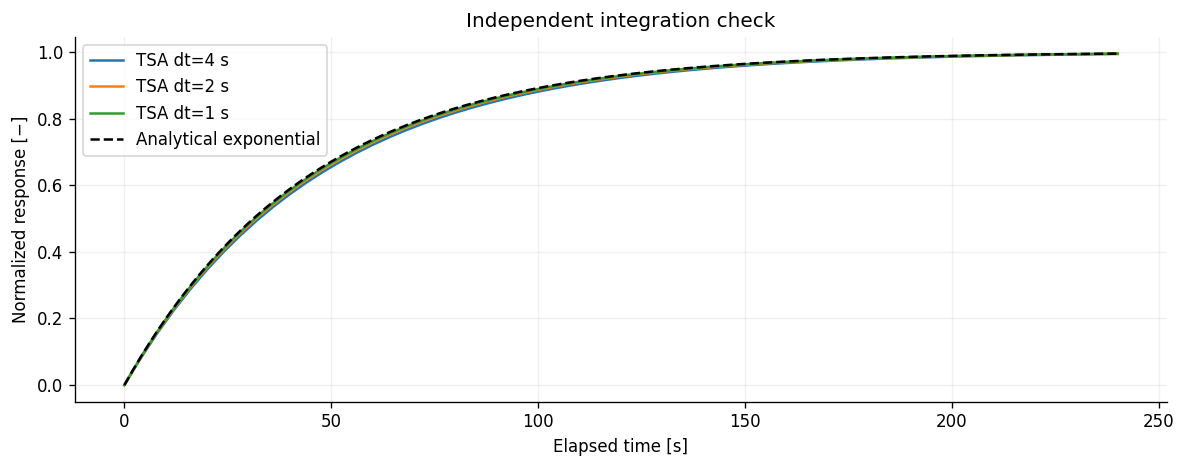

,dt [s],Max normalized error
0,4.0,0.015759
1,2.0,0.008027
2,1.0,0.004050


In [12]:
step_rows = []
fig, ax = plt.subplots(figsize=(10, 4))
for step in [4.0, 2.0, 1.0]:
    step_times = np.arange(0, 240 + step, step)
    model = unit_model(f"Step {step}", [1.0], tau=tau_true)
    values = []
    for index, instant in enumerate(step_times):
        values.append(model.Iterate(netarray([0.0 if index == 0 else 1.0]), step)[0])
    exact = 1 - np.exp(-step_times / tau_true)
    error = np.max(abs(np.array(values) - exact))
    step_rows.append({"dt [s]": step, "Max normalized error": error})
    ax.plot(step_times, values, label=f"TSA dt={step:g} s")
ax.plot(step_times, exact, "k--", label="Analytical exponential")
ax.set(
    xlabel="Elapsed time [s]",
    ylabel="Normalized response [−]",
    title="Independent integration check",
)
ax.legend()
finish(fig, "08_timestep")
display(pd.DataFrame(step_rows))
check(
    "Time-step refinement reduces error",
    step_rows[2]["Max normalized error"]
    < step_rows[1]["Max normalized error"]
    < step_rows[0]["Max normalized error"],
    step_rows,
)

## 6. Connect the reduced models into a plant

TimeSeriesAnalysis can execute a network of connected unit models. We instantiate six copies of the identified cooler, prescribe different effective time constants for their different assumed inventories, and connect them to a common export-temperature signal. Each train has two external temperature inputs. A cooling-water disturbance reaches all trains; individual hot-inlet changes occur at different times.

The header model uses fixed gas-mass weights and a 12 s sensor lag. A mass-weighted temperature is an approximation valid for similar compositions and heat capacities. The exact NeqSim header uses enthalpy mixing. No pressure coupling or shared cooling-water feedback is implied by this feed-forward network.

Connected network runtime: 0.031 s


,Train,Header weight [−],Initial outlet [°C],Final outlet [°C]
0,Train A,0.1667,32.0035,35.4429
1,Train B,0.1667,32.0035,35.4429
2,Train C,0.1667,32.0035,35.4429
3,Train D,0.1667,32.0035,35.4429
4,Train E,0.1667,32.0035,35.4429
5,Train F,0.1667,32.0035,35.4429


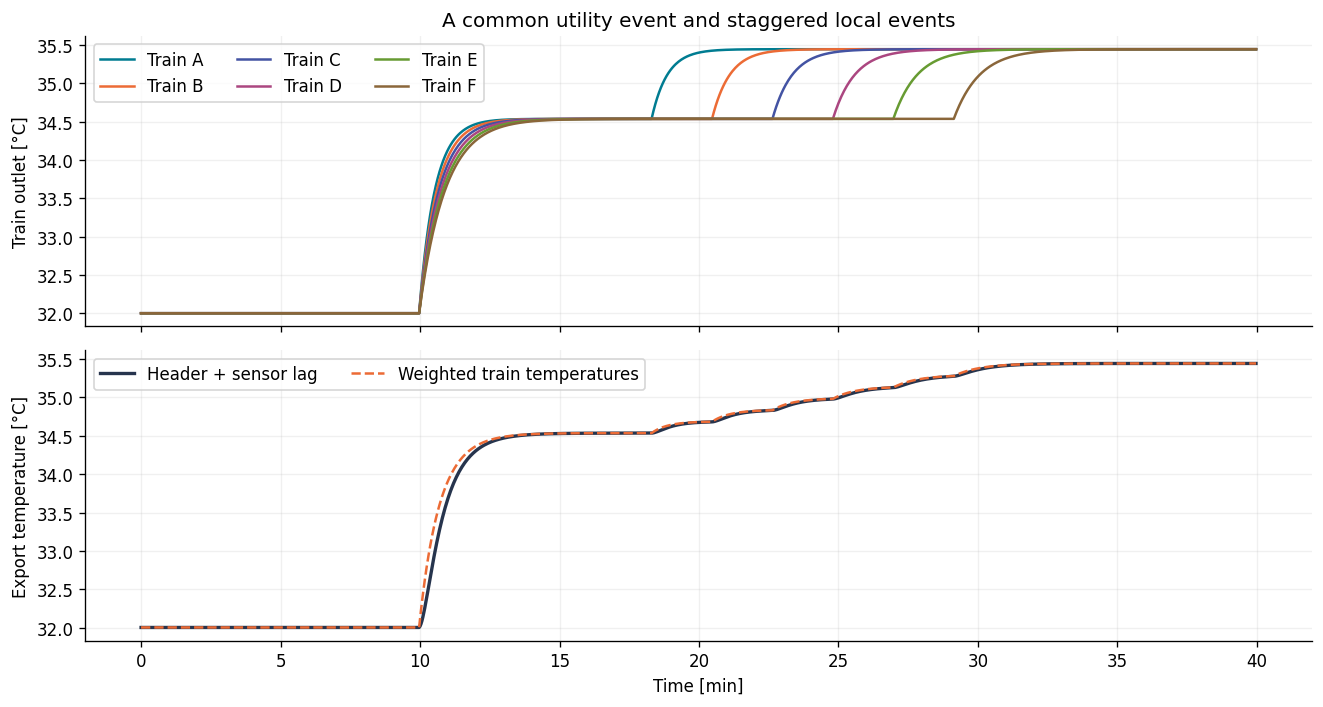

In [13]:
network_models = List[ISimulatableModel]()
cooler_models = []
for index, name in enumerate(TRAIN_NAMES):
    parameters = fit_parameters.CreateCopy()
    parameters.TimeConstant_s *= 0.75 + 0.1 * index
    model = UnitModel(parameters, f"cooler_{index}")
    cooler_models.append(model)
    network_models.Add(model)
weights = baseline["Export [kg/s]"].values / baseline["Export [kg/s]"].sum()
header_model = unit_model("export_temperature", weights, tau=12.0)
network_models.Add(header_model)
network = PlantSimulator(network_models, "Six-train thermal twin", "Synthetic identified network")
network_data = TimeSeriesDataSet()
network_count = 1200
network_seconds = np.arange(network_count) * dt
network_coolant = np.full(network_count, coolant_reference)
network_coolant[300:] += 3.0
for index, model in enumerate(cooler_models):
    network.ConnectModels(model, header_model, index)
    hot_input = np.full(network_count, hot_temperature)
    hot_input[550 + 65 * index :] += 6.0
    hot_signal = network.AddExternalSignal(model, SignalType.External_U, 0)
    coolant_signal = network.AddExternalSignal(model, SignalType.External_U, 1)
    network_data.Add(hot_signal, netarray(hot_input))
    network_data.Add(coolant_signal, netarray(network_coolant))
network_data.CreateTimestamps(dt, network_count)
network_start = time.perf_counter()
network_ok, network_output = network.Simulate(network_data)
network_seconds_elapsed = time.perf_counter() - network_start
check("Connected TSA plant simulation", network_ok, f"7 models × {network_count} time steps")
network_temperatures = np.column_stack(
    [list(network_output.GetValues(model.GetOutputID())) for model in cooler_models]
)
header_temperature = np.array(list(network_output.GetValues(header_model.GetOutputID())))
check(
    "Finite network outputs",
    np.isfinite(network_temperatures).all() and np.isfinite(header_temperature).all(),
    f"{network_temperatures.size + header_temperature.size} output samples",
)
display(
    pd.DataFrame(
        {
            "Train": TRAIN_NAMES,
            "Header weight [−]": weights,
            "Initial outlet [°C]": network_temperatures[0],
            "Final outlet [°C]": network_temperatures[-1],
        }
    ).round(4)
)
print(f"Connected network runtime: {network_seconds_elapsed:.3f} s")
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for index, name in enumerate(TRAIN_NAMES):
    axes[0].plot(
        network_seconds / 60, network_temperatures[:, index], color=COLORS[index], label=name
    )
axes[0].set(ylabel="Train outlet [°C]", title="A common utility event and staggered local events")
axes[0].legend(ncol=3)
axes[1].plot(
    network_seconds / 60, header_temperature, color="#26344D", lw=2, label="Header + sensor lag"
)
axes[1].plot(
    network_seconds / 60,
    network_temperatures @ weights,
    color=COLORS[1],
    ls="--",
    label="Weighted train temperatures",
)
axes[1].set(xlabel="Time [min]", ylabel="Export temperature [°C]")
axes[1].legend(ncol=2)
finish(fig, "09_connected_network")

## 7. Diagnose compressor degradation with physical residuals

A higher power reading can reflect increased flow, pressure ratio, reduced efficiency or a faulty meter. First calculate the expected power and discharge temperature with NeqSim at each observed operating condition. Then monitor deviations from that moving physical baseline.

We generate 96 independent steady historian windows for Train A's **first compressor**, varying feed flow and suction pressure. Windows 0–63 are healthy, 64–83 have a five-percentage-point efficiency loss, and 84–95 return to healthy operation but have a positive power-meter offset. These labels generate and evaluate the synthetic case; the residual classifier does not receive them.

$$r_W=W_{measured}-W_{NeqSim},\qquad r_T=T_{measured}-T_{NeqSim}$$

Power residuals are in MW; temperature residuals are in K. Standardize each residual using the first 40 healthy windows, then use a causal exponential moving average. A sustained increase in both residuals suggests a physical efficiency change; an isolated power residual suggests a measurement or driver-model discrepancy. This is diagnostic evidence, not unique proof of the root cause. Composition errors, heat transfer, driver losses and sensor bias can confound this interpretation in a real plant.

Full NeqSim monitoring calculations: 8.48 s
Efficiency-change detection delay: 0 historian windows


,Window,Feed [kg/s],Suction [bara],Power measured [MW],Power expected [MW],Discharge measured [°C],Discharge expected [°C],Diagnosis
40,40,18.653,28.240,2.557,2.562,115.264,115.294,within baseline
63,63,21.030,31.699,2.434,2.439,105.444,105.478,within baseline
65,65,20.347,31.862,2.516,2.341,108.041,105.032,physical change candidate
75,75,17.598,31.721,2.165,2.041,108.540,105.474,physical change candidate
85,85,18.973,30.253,2.576,2.363,109.469,109.440,physical change candidate
95,95,22.110,28.590,3.199,2.988,114.333,114.282,power measurement/model candidate


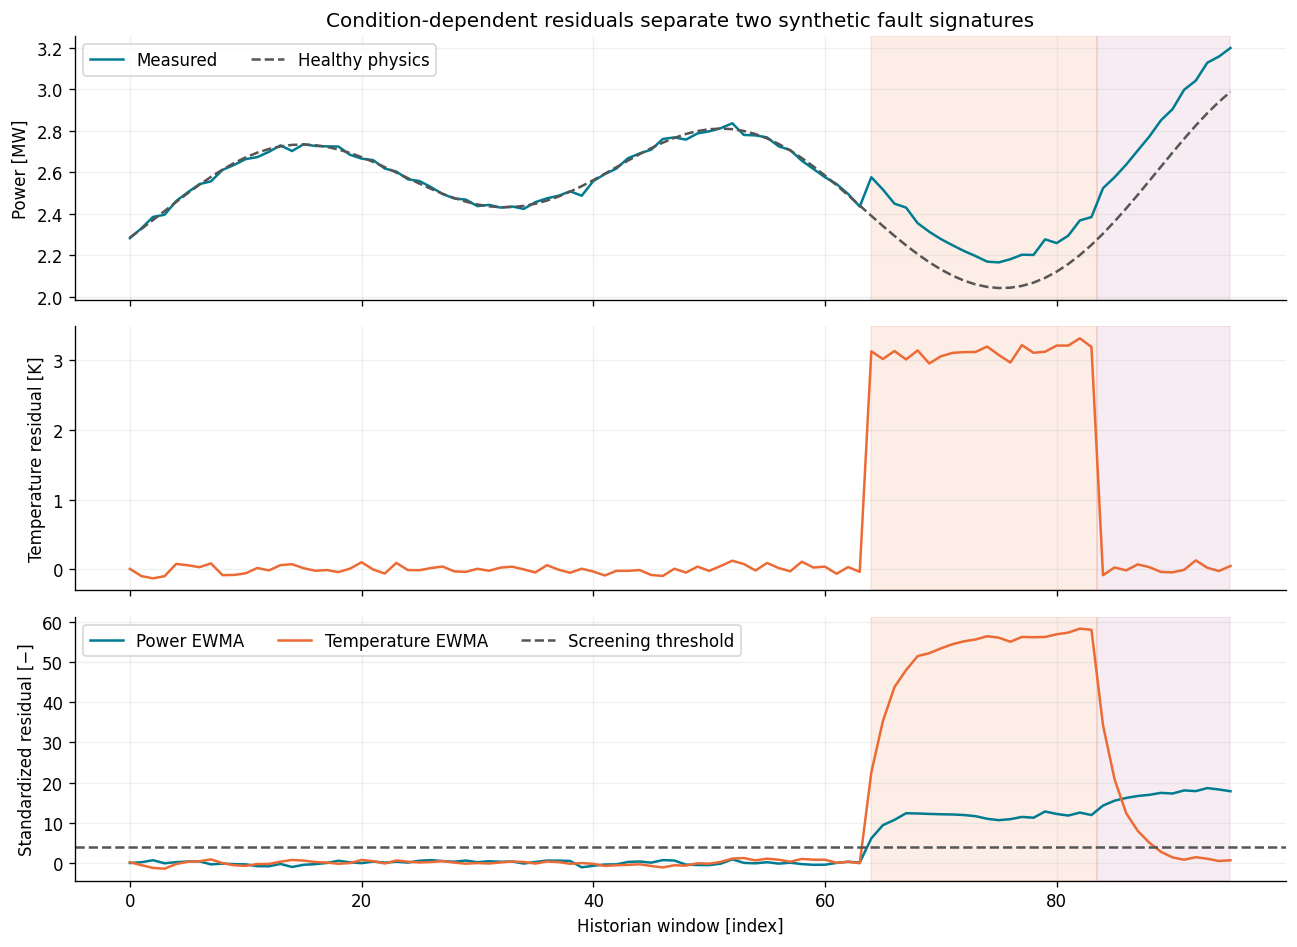

In [14]:
def compressor_point(rate, suction, efficiency):
    train = build_train("Diagnostic compressor", float(rate), float(efficiency), float(suction))
    train["process"].run()
    first = train["compressors"][0]
    return first.getPower("kW") / 1000.0, first.getOutletStream().getTemperature("C")


monitor_count = 96
window = np.arange(monitor_count)
monitor_rng = np.random.default_rng(2048)
monitor_rate = 20 + 2.5 * np.sin(window / 7)
monitor_pressure = 30 + 2 * np.cos(window / 11)
true_eta = np.full(monitor_count, ETA_NOMINAL[0])
true_eta[64:84] -= 0.05
monitor_start = time.perf_counter()
healthy_prediction = np.array(
    [
        compressor_point(rate, pressure, ETA_NOMINAL[0])
        for rate, pressure in zip(monitor_rate, monitor_pressure)
    ]
)
plant_observation = healthy_prediction.copy()
for index in range(64, 84):
    plant_observation[index] = compressor_point(
        monitor_rate[index], monitor_pressure[index], true_eta[index]
    )
plant_observation += monitor_rng.normal(size=(monitor_count, 2)) * [0.012, 0.06]
plant_observation[84:, 0] += 0.22
monitor_seconds_elapsed = time.perf_counter() - monitor_start
physical_residuals = plant_observation - healthy_prediction
calibration_mean = physical_residuals[:40].mean(axis=0)
calibration_scale = physical_residuals[:40].std(axis=0, ddof=1)
standard_residuals = (physical_residuals - calibration_mean) / calibration_scale
smoothed_residuals = pd.DataFrame(standard_residuals).ewm(alpha=0.4, adjust=False).mean().values
power_alarm = smoothed_residuals[:, 0] > 4
temperature_alarm = smoothed_residuals[:, 1] > 4
diagnosis = np.full(monitor_count, "within baseline", dtype=object)
diagnosis[power_alarm & temperature_alarm] = "physical change candidate"
diagnosis[power_alarm & ~temperature_alarm] = "power measurement/model candidate"
monitoring = pd.DataFrame(
    {
        "Window": window,
        "Feed [kg/s]": monitor_rate,
        "Suction [bara]": monitor_pressure,
        "Power measured [MW]": plant_observation[:, 0],
        "Power expected [MW]": healthy_prediction[:, 0],
        "Discharge measured [°C]": plant_observation[:, 1],
        "Discharge expected [°C]": healthy_prediction[:, 1],
        "Diagnosis": diagnosis,
    }
)
healthy_false_alarms = int(np.sum(power_alarm[40:64] | temperature_alarm[40:64]))
physical_detection = np.flatnonzero(
    (window >= 64) & (window < 84) & power_alarm & temperature_alarm
)
check(
    "Detect injected efficiency change",
    len(physical_detection) > 0,
    f"First detected window {physical_detection[0] if len(physical_detection) else 'none'}",
)
check(
    "Healthy validation remains quiet",
    healthy_false_alarms <= 1,
    f"{healthy_false_alarms} flagged windows of 24",
)
print(f"Full NeqSim monitoring calculations: {monitor_seconds_elapsed:.2f} s")
print(f"Efficiency-change detection delay: {physical_detection[0] - 64} historian windows")
display(monitoring.iloc[[40, 63, 65, 75, 85, 95]].round(3))
fig, axes = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axes[0].plot(window, plant_observation[:, 0], color=COLORS[0], label="Measured")
axes[0].plot(window, healthy_prediction[:, 0], color="#555555", ls="--", label="Healthy physics")
axes[0].set(
    ylabel="Power [MW]",
    title="Condition-dependent residuals separate two synthetic fault signatures",
)
axes[0].legend(ncol=2)
axes[1].plot(window, physical_residuals[:, 1], color=COLORS[1])
axes[1].set(ylabel="Temperature residual [K]")
axes[2].plot(window, smoothed_residuals[:, 0], color=COLORS[0], label="Power EWMA")
axes[2].plot(window, smoothed_residuals[:, 1], color=COLORS[1], label="Temperature EWMA")
axes[2].axhline(4, color="#555555", ls="--", label="Screening threshold")
axes[2].set(xlabel="Historian window [index]", ylabel="Standardized residual [−]")
axes[2].legend(ncol=3)
for ax in axes:
    ax.axvspan(64, 83.5, color=COLORS[1], alpha=0.12)
    ax.axvspan(83.5, 95, color=COLORS[3], alpha=0.10)
finish(fig, "10_compressor_diagnostics")

### Estimate a parameter and cross-check a second sensor

For one flagged window, solve for the compressor efficiency that explains measured power, then predict discharge temperature without fitting that temperature. For comparison, repeat at a window containing only a power-meter bias. The synthetic efficiency curve's off-design term is preserved in both forward and inverse calculations.

The fitted parameter is the nominal isentropic efficiency, before the stated off-design correction. A successful scalar inverse solution by itself is insufficient; the independent temperature check makes the engineering interpretation more useful.

In [15]:
inverse_rows = []
for sample, label in [(75, "Efficiency-loss window"), (95, "Power-meter-offset window")]:

    def power_mismatch(efficiency):
        modeled_power, _ = compressor_point(
            monitor_rate[sample], monitor_pressure[sample], efficiency
        )
        return modeled_power - plant_observation[sample, 0]

    estimated_eta = brentq(power_mismatch, 0.55, 0.88, xtol=1e-6)
    _, independent_temperature = compressor_point(
        monitor_rate[sample], monitor_pressure[sample], estimated_eta
    )
    inverse_rows.append(
        {
            "Case": label,
            "Nominal efficiency estimate [−]": estimated_eta,
            "Injected nominal efficiency [−]": true_eta[sample],
            "Independent temperature error [K]": independent_temperature
            - plant_observation[sample, 1],
        }
    )
inverse_results = pd.DataFrame(inverse_rows).set_index("Case")
display(inverse_results.round(4))
check(
    "Efficiency inverse recovery",
    abs(inverse_rows[0]["Nominal efficiency estimate [−]"] - true_eta[75]) < 0.01,
    inverse_rows[0],
)
check(
    "Temperature distinguishes meter-only case",
    abs(inverse_rows[1]["Independent temperature error [K]"]) > 1.0,
    inverse_rows[1],
)

,Nominal efficiency estimate [−],Injected nominal efficiency [−],Independent temperature error [K]
Case,,,
Efficiency-loss window,0.7356,0.73,-0.3616
Power-meter-offset window,0.7286,0.78,3.6117


## 8. PID screening with the identified dynamic model

Use `PidModel` to regulate the identified aftercooler temperature by manipulating a cooling-water temperature command. This idealized command has engineering units of °C and an assumed physical actuator range of 8–28 °C. It is not a valve percentage. The actuator is clamped explicitly after the library's controller output; saturation is counted. The selected test remains unsaturated so it does not claim qualification of anti-windup behavior.

For this positive-gain input, increasing cooling-water temperature raises the outlet temperature. The PI controller is initialized at the reference steady state and uses a conservative gain derived from the identified gain and time constant. A +7 K hot-inlet disturbance is applied at 200 s. We compare two tuning speeds against the same reduced plant and report integral absolute error and peak deviation.

$$IAE=\int_0^{t_f}|T(t)-T_{set}|\,dt$$

$IAE$ is in K·s. This is an offline control-screening example; equipment-specific limits, interaction, dead time and real closed-loop data are needed for controller deployment.

,Tuning lambda [s],IAE [K s],Peak deviation [K],Saturated samples,Final offset [K]
0,45.0,47.6374,0.3955,0,0.0
1,90.0,95.2746,0.5347,0,0.0


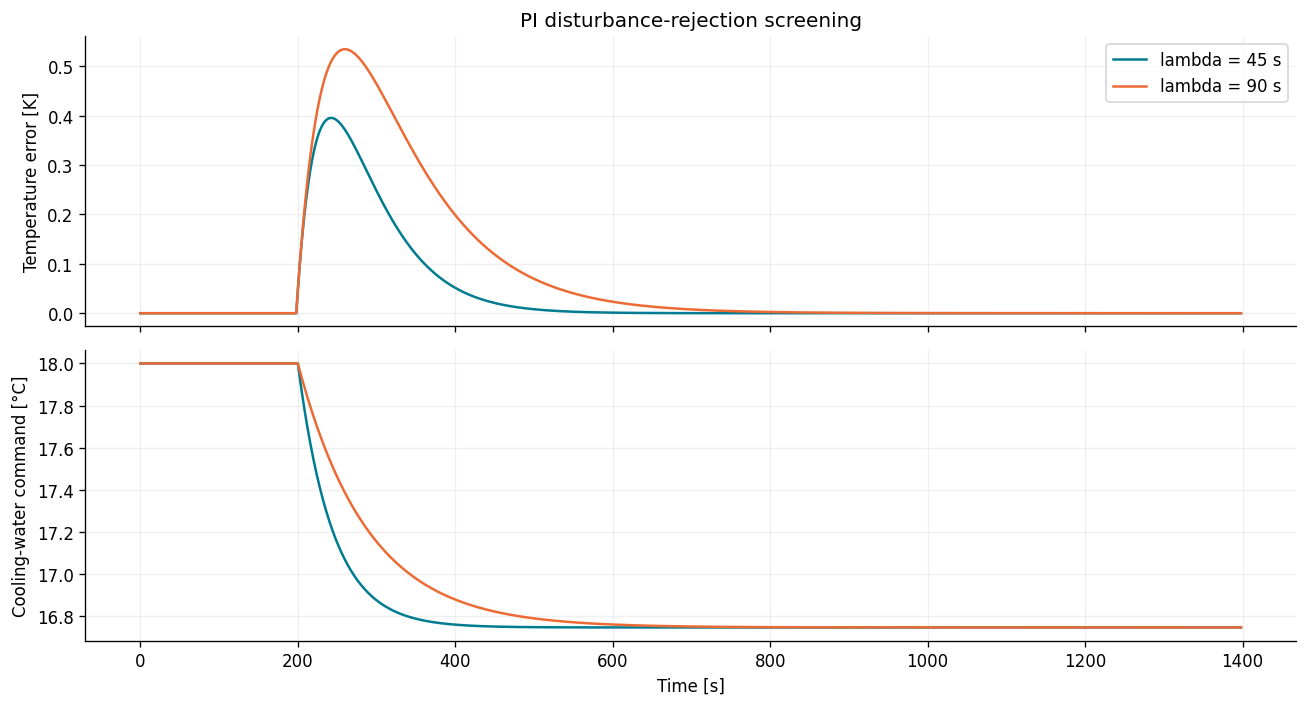

In [16]:
controller_count = 700
control_time = np.arange(controller_count) * dt
control_setpoint = float(
    identified.GetSteadyStateOutput(netarray([hot_temperature, coolant_reference]))
)


def run_control(lambda_seconds):
    process_parameters = fit_parameters.CreateCopy()
    controlled_process = UnitModel(process_parameters, f"Controlled cooler {lambda_seconds}")
    pid_parameters = PidParameters()
    pid_parameters.Kp = float(fit_parameters.TimeConstant_s / (fit_gains[1] * lambda_seconds))
    pid_parameters.Ti_s = float(fit_parameters.TimeConstant_s)
    pid_parameters.u0 = coolant_reference
    controller = PidModel(pid_parameters, f"Temperature PI {lambda_seconds}")
    controller.WarmStart(control_setpoint, control_setpoint, coolant_reference)
    outlet = control_setpoint
    values, commands = [], []
    saturation_count = 0
    for instant in control_time:
        raw_command = controller.Iterate(netarray([outlet, control_setpoint]), dt)[0]
        command = float(np.clip(raw_command, 8, 28))
        saturation_count += int(abs(raw_command - command) > 1e-8)
        inlet = hot_temperature + (7.0 if instant >= 200 else 0.0)
        outlet = controlled_process.Iterate(netarray([inlet, command]), dt)[0]
        values.append(outlet)
        commands.append(command)
    values = np.array(values)
    return (
        values,
        np.array(commands),
        {
            "Tuning lambda [s]": lambda_seconds,
            "IAE [K s]": float(np.sum(abs(values - control_setpoint)) * dt),
            "Peak deviation [K]": float(np.max(abs(values - control_setpoint))),
            "Saturated samples": saturation_count,
            "Final offset [K]": float(values[-1] - control_setpoint),
        },
    )


control_runs = [run_control(value) for value in [45.0, 90.0]]
control_summary = pd.DataFrame([result[2] for result in control_runs])
display(control_summary.round(4))
check(
    "Control returns to setpoint",
    control_summary["Final offset [K]"].abs().max() < 0.01,
    control_summary["Final offset [K]"].tolist(),
)
check(
    "Control demonstration is unsaturated",
    control_summary["Saturated samples"].sum() == 0,
    control_summary["Saturated samples"].tolist(),
)
fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
for index, (values, commands, summary) in enumerate(control_runs):
    label = f"lambda = {summary['Tuning lambda [s]']:g} s"
    axes[0].plot(control_time, values - control_setpoint, color=COLORS[index], label=label)
    axes[1].plot(control_time, commands, color=COLORS[index], label=label)
axes[0].set(ylabel="Temperature error [K]", title="PI disturbance-rejection screening")
axes[0].legend()
axes[1].set(xlabel="Time [s]", ylabel="Cooling-water command [°C]")
finish(fig, "11_pid_screening")

## 9. Scale by separating expensive physics from frequent inference

The facility object retains the detailed unit models. A production analytics service can update physical operating points when composition, pressure, equipment state or operating region changes, then run qualified reduced models at the historian sampling rate. Revalidate after maintenance, sensor changes or excursions beyond the training envelope.

The following timings are observations from this runtime. The workloads differ, so their ratio must not be presented as a like-for-like simulator speedup. The network benchmark holds 200 samples fixed and increases the number of connected first-order models. Construction and Python-to-.NET data preparation are excluded from its simulation timing and are measured separately.

For process scale, use explicit tag-to-equipment mappings and fixed units, quality masks, chronological qualification windows and versioned model registries. Share plain numeric arrays or tables across worker processes; do not share mutable Java or .NET process objects between unsynchronized workers. The notebook uses serial calls for reproducibility.

,Parallel units,Connected models,Time samples,Preparation [s],Simulation [s],Output samples/s
0,6,7,200,0.006,0.005,259838.073
1,24,25,200,0.005,0.011,455656.677
2,96,97,200,0.013,0.080,241276.409


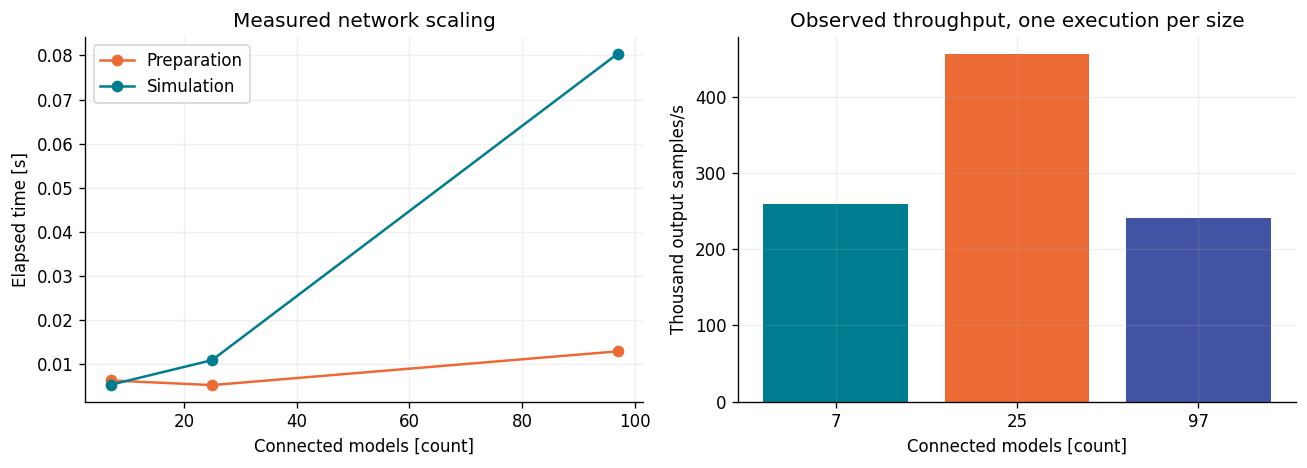

In [17]:
scaling_rows = []
for copies in [6, 24, 96]:
    prepare_start = time.perf_counter()
    fleet = List[ISimulatableModel]()
    fleet_units = [unit_model(f"unit_{index}", [1.0], tau=45.0) for index in range(copies)]
    for model in fleet_units:
        fleet.Add(model)
    aggregate = unit_model("fleet_mean", np.full(copies, 1 / copies))
    fleet.Add(aggregate)
    fleet_network = PlantSimulator(fleet, f"Fleet {copies}", "Scaling experiment")
    fleet_data = TimeSeriesDataSet()
    fleet_input = np.zeros(200)
    fleet_input[30:] = 1.0
    for index, model in enumerate(fleet_units):
        fleet_network.ConnectModels(model, aggregate, index)
        signal = fleet_network.AddExternalSignal(model, SignalType.External_U, 0)
        fleet_data.Add(signal, netarray(fleet_input))
    fleet_data.CreateTimestamps(dt, len(fleet_input))
    prepare_seconds = time.perf_counter() - prepare_start
    started = time.perf_counter()
    success, fleet_output = fleet_network.Simulate(fleet_data)
    elapsed = time.perf_counter() - started
    check(f"Connected fleet {copies}", success, f"{copies + 1} models")
    final_mean = float(list(fleet_output.GetValues(aggregate.GetOutputID()))[-1])
    check(f"Fleet {copies} aggregate bound", 0.99 < final_mean <= 1.0, final_mean)
    scaling_rows.append(
        {
            "Parallel units": copies,
            "Connected models": copies + 1,
            "Time samples": 200,
            "Preparation [s]": prepare_seconds,
            "Simulation [s]": elapsed,
            "Output samples/s": (copies + 1) * 200 / elapsed,
        }
    )
scaling = pd.DataFrame(scaling_rows)
display(scaling.round(3))
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(
    scaling["Connected models"],
    scaling["Preparation [s]"],
    "o-",
    label="Preparation",
    color=COLORS[1],
)
axes[0].plot(
    scaling["Connected models"],
    scaling["Simulation [s]"],
    "o-",
    label="Simulation",
    color=COLORS[0],
)
axes[0].set(
    xlabel="Connected models [count]", ylabel="Elapsed time [s]", title="Measured network scaling"
)
axes[0].legend()
axes[1].bar(
    scaling["Connected models"].astype(str), scaling["Output samples/s"] / 1000, color=COLORS[:3]
)
axes[1].set(
    xlabel="Connected models [count]",
    ylabel="Thousand output samples/s",
    title="Observed throughput, one execution per size",
)
finish(fig, "12_scaling")

## 10. Evidence, interpretation and export

The notebook's evidence reaches conservation checks and comparison against an independent analytical thermal solution. The dynamic and diagnostic observations are synthetic. They establish that the integration and algorithms work in these controlled cases; they do not establish plant accuracy or field detection rates.

| Question | What is demonstrated | Important boundary |
|---|---|---|
| Can the libraries coexist? | Verified JVM and CoreCLR loaded in one Python process | Restart before changing assemblies |
| Can a large process be represented? | Six NeqSim trains, 67 units and a common header | No recycle or pressure-network solution |
| Can operating load be optimized? | Bounded interpolation search and NeqSim replay | Assumed efficiency curves; local candidate |
| Can dynamics be identified? | Actual TSA identification, chronological test and time-step check | Lumped fixed-property cooler model |
| Can faults be distinguished? | Power/temperature residuals and independent sensor cross-check | Synthetic faults; competing causes remain |
| Can connected models scale? | Actual PlantSimulator runs up to 97 connected models | Small fixed sample count; no universal speedup claim |
| Can control be screened? | Actual PidModel against an identified process | Ideal cooling-water actuator; unsaturated test |

Exports include the measured/synthetic historian series, quality mask, operating scan, allocation, diagnostic results, model parameters and validation evidence. Figures remain embedded in the notebook and are also saved as PNG files. The directory is created in the current notebook working directory; in Colab, download it from the Files pane.

In [18]:
validation = pd.DataFrame(checks)
display(validation)
check(
    "All recorded engineering checks passed",
    bool(validation.Passed.all()),
    f"{len(validation)} prior checks",
)
summary = {
    "facility_units": unit_count,
    "facility_feed_kg_s": float(baseline["Feed [kg/s]"].sum()),
    "facility_power_MW": float(baseline["Power [MW]"].sum()),
    "candidate_power_saving_MW": float(saving_mw),
    "held_out_dynamic_rmse_K": float(scores.loc["Held-out test", "TSA dynamic RMSE [K]"]),
    "held_out_static_rmse_K": float(scores.loc["Held-out test", "Static regression RMSE [K]"]),
    "physical_fault_detection_delay_windows": int(physical_detection[0] - 64),
    "healthy_validation_alarm_windows": healthy_false_alarms,
    "engineering_checks_passed": len(checks),
    "static_figures": len(figures),
}
parameter_export = {
    "input_tags": ["hot_inlet_C", "cooling_water_C"],
    "output_tag": "outlet_C",
    "linear_gains": list(fit_parameters.LinearGains),
    "input_reference": list(fit_parameters.U0),
    "bias": float(fit_parameters.Bias),
    "time_constant_s": float(fit_parameters.TimeConstant_s),
    "time_delay_s": float(fit_parameters.TimeDelay_s),
    "sample_interval_s": dt,
    "training_samples": train_end,
    "calibration_end": calibration_end,
    "calibration_abs_residual_threshold_K": calibration_threshold,
    "dynamic_training_domain": {
        "hot_inlet_C": [float(inputs[:train_end, 0].min()), float(inputs[:train_end, 0].max())],
        "cooling_water_C": [
            float(inputs[:train_end, 1].min()),
            float(inputs[:train_end, 1].max()),
        ],
        "fixed_gas_flow_kg_s": float(gas_flow),
        "fixed_cp_kJ_kgK": float(cp),
    },
    "separate_steady_response_domain": {
        "feed_kg_s": [13, 27],
        "suction_bara": 30,
        "export_bara": 180,
    },
}
for filename, frame in {
    "facility_baseline.csv": baseline,
    "operating_scan.csv": scan,
    "allocation.csv": allocation,
    "historian_clean.csv": historian,
    "historian_raw.csv": raw_historian,
    "quality_flags.csv": quality,
    "compressor_monitoring.csv": monitoring,
    "inverse_diagnostics.csv": inverse_results,
    "scaling.csv": scaling,
    "validation.csv": pd.DataFrame(checks),
}.items():
    frame.to_csv(outdir / filename)
(outdir / "identified_model.json").write_text(json.dumps(parameter_export, indent=2))
(outdir / "provenance.json").write_text(json.dumps(provenance, indent=2))
(outdir / "summary.json").write_text(json.dumps(summary, indent=2))
archive_path = shutil.make_archive(str(outdir), "zip", outdir)
display(pd.Series(summary, name="Computed outcome").to_frame())
print(f"Saved {len(list(outdir.iterdir()))} result files and {archive_path}")

Saved 25 result files and /workspace/scratch/9af6cc165f55/neqsim_tsa_results.zip


,Check,Passed,Evidence
0,Mole fractions sum to one,True,"{'methane': 0.82, 'ethane': 0.08, 'propane': 0.045, 'n-butane': 0.025, 'n-pentane': 0.012, 'n-hexane': 0.007, 'CO2': 0.009, 'water': 0.002}"
1,Train total mass balances,True,1.9617918400882672e-11
2,Train enthalpy balances,True,2.4556356947869062e-11
3,Component molar balances,True,9.948747990190384e-13
4,Header mass balance,True,-2.842170943040401e-14
5,Header energy balance,True,0.0
6,Physical power and cooling signs,True,All compressor powers and cooling requirements positive
7,Scan balance closure,True,3.456079866737127e-11
8,Load allocation solver,True,Optimization terminated successfully
9,Replay fixed total feed,True,120.00000000000001


,Computed outcome
facility_units,67.000000
facility_feed_kg_s,120.000000
facility_power_MW,32.079332
candidate_power_saving_MW,0.050776
held_out_dynamic_rmse_K,0.026372
held_out_static_rmse_K,1.281137
physical_fault_detection_delay_windows,0.000000
healthy_validation_alarm_windows,0.000000
engineering_checks_passed,36.000000
static_figures,12.000000


## 11. How to extend this into an industrial study

**Start with one qualified process section.** Map historian tags to the exposed NeqSim stream and equipment objects. State whether each flow is mass, molar, standard volume or actual volume. Record absolute versus gauge pressure and clock alignment. Estimate process delays before matching measurements with predictions.

**Choose the dynamic fidelity deliberately.** For plant-wide monitoring, use TSA unit models where the operating regime is stable and the dominant dynamics are identifiable. For vessel inventory, phase redistribution, network hydraulics or slugging, qualify the appropriate native NeqSim dynamic equipment and connect its time-stamped outputs to the same analytics interface. Do not obtain a transient model merely by calling a steady process repeatedly.

**Improve uncertainty and discrimination.** Add composition uncertainty and independent flow/temperature sensors. Use blocked resampling and residual autocorrelation checks before treating alarm thresholds as probabilities. Here the threshold is an empirical calibration quantile, not a guaranteed coverage bound. Validate closed-loop identification separately because controller action correlates inputs, outputs and disturbances.

**Add operation-specific constraints.** Compressor maps, surge margin, shaft speed, cooler capacity, liquid handling and pressure-drop constraints can change the optimum. A real cooling system needs a coupled return-water balance and exchanger relations; the fixed-temperature cooler and prescribed utility event in this notebook do not provide that model.

### Exercises

1. Reduce Train E's driver rating by 10%, rerun allocation and identify the binding constraints.
2. Replace the thermal capacitance with a geometry-based metal and fluid inventory estimate. Compare identified and physical time constants.
3. Add a 10 s transport delay and enable delay estimation. Keep a separate held-out segment.
4. Add correlated sensor noise and repeat the alarm calibration. Inspect residual autocorrelation before choosing persistence thresholds.
5. Introduce a composition shift in the NeqSim diagnostic plant. Determine whether the two-residual signature can still distinguish efficiency from composition.
6. Replace the header temperature approximation with repeated NeqSim enthalpy mixing and quantify its error across a composition envelope.

### Sources and API references

- [NeqSim source revision used here](https://github.com/equinor/neqsim/tree/f3e588cec56fce818b723b3c0cb94c3619509d41): process systems, compressors, coolers, separators and SRK properties.
- [Equinor TimeSeriesAnalysis](https://github.com/equinor/TimeSeriesAnalysis) and [NuGet 1.4.38](https://www.nuget.org/packages/TimeSeriesAnalysis/1.4.38): Apache-2.0 industrial time-series modeling library.
- [Python.NET integration](https://equinor.github.io/TimeSeriesAnalysis/articles/python.html): loading the .NET assembly from Python.
- [UnitIdentifier documentation](https://equinor.github.io/TimeSeriesAnalysis/articles/unitIdentifier.html): identification structure and parameters.
- [UnitModel source](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/Dynamic/SimulatableModels/UnitModel.cs), [PlantSimulator source](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/Dynamic/PlantSimulator/PlantSimulator.cs) and [LowPass discretization](https://github.com/equinor/TimeSeriesAnalysis/blob/c8d65e97fe8a0ce8b79d3d8dd3867de4bbe6edaf/TimeSeriesAnalysis/Filters/LowPass.cs): exact API and numerical behavior inspected during authoring.
- Related notebooks: [data reconciliation and Bayesian digital twin](../process/data_reconciliation_bayesian_digital_twin.ipynb), [wellstream steady and dynamic flow](../fluidflow/wellstream_steady_dynamic_multiphase_master.ipynb), and [examples catalog](../examples_of_NeqSim_in_Colab.ipynb).

No new NeqSim library defect was identified in the validated scope. The deliberately simplified dynamic storage, cooling network and control-actuator models are notebook assumptions, not claims that those capabilities are absent from NeqSim.